
# Pourquoi le PINN aérodynamique pur ne donne pas une aile portante

Ce notebook est conçu pour être montré au professeur. Il reproduit de manière structurée les essais réalisés pendant le projet :

1. formulation PINN Navier--Stokes stationnaire autour d'un NACA 2412 ;
2. conditions aux limites et pression de référence ;
3. tentatives d'amélioration : domaine plus grand, pression gauge ponctuelle, suppression de `far Cp`, Fourier features, boost près du profil, Kutta locale, sweep en Reynolds ;
4. comparaison avec les runs utilisant une supervision XFOIL ;
5. diagnostic visuel : pertes, distribution de pression, portance intégrée.

Le point important à montrer n'est pas que le code « plante », mais que la formulation PINN pure converge vers une branche quasi non portante : vitesse proche du freestream, pression trop symétrique, et donc \(C_L \approx 0\), même quand on change plusieurs détails numériques.



## Mode d'utilisation

Deux modes sont possibles.

**Mode rapide** : charger les résultats déjà pré-calculés dans `OUTDIR` et faire les figures.

**Mode reproduction complète** : lancer la suite d'expériences avant la présentation, puis ouvrir ce notebook. La commande recommandée est :

```bash
python -u run_pinn_failure_suite_v2.py \
  --preset full \
  --outdir runs_pinn_failure_v2_full \
  --cp-data-csv xfoil_cp_dataset_naca2412_dense_Re200k/xfoil_cp_dataset.csv
```

Si le CSV XFOIL n'est pas disponible, retirer l'option `--cp-data-csv`. Les cas pure PINN et Re-sweep seront quand même lancés.

Pour une version plus longue :

```bash
python -u run_pinn_failure_suite_v2.py \
  --preset overnight \
  --outdir runs_pinn_failure_v2_overnight \
  --cp-data-csv xfoil_cp_dataset_naca2412_dense_Re200k/xfoil_cp_dataset.csv
```


In [1]:

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pinn_airfoil_failure_lab_v2 as lab

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

OUTDIR = Path("runs_pinn_failure_v2_full")
CPDATA = Path("xfoil_cp_dataset_naca2412_dense_Re200k/xfoil_cp_dataset.csv")
print("OUTDIR exists:", OUTDIR.exists())
print("CPDATA exists:", CPDATA.exists())


OUTDIR exists: True
CPDATA exists: False



## 1. Géométrie et intégration de surface

On utilise un NACA 2412, centré en corde : bord d'attaque en \(x=-0.5\), bord de fuite en \(x=+0.5\). La pression est intégrée sur des segments de surface par :

\[
\mathbf F_p^* \simeq -\sum_i C_{p,i}\,\mathbf n_i\,\Delta s_i.
\]

Le même quadrature est utilisé dans les diagnostics Python et dans le composant Unreal V2.


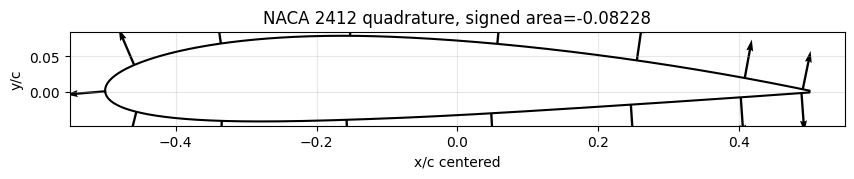

{'area': -0.08228142559528351, 'perimeter': 2.043919563293457, 'half': 450}


In [2]:

surface = lab.build_surface_quadrature(n_per_side=450)
fig, ax = plt.subplots(figsize=(10, 3))
lab.plot_airfoil_geometry(surface, ax=ax, normal_stride=60)
plt.show()
print({k: surface[k] for k in ["area", "perimeter", "half"]})



## 2. Table historique : ce qu'on a observé dans les vrais runs V8

Avant de relancer les expériences, on rappelle les résultats historiques du projet. Le sweep Reynolds sans données XFOIL montrait que la portance restait de l'ordre de \(10^{-4}\) à \(10^{-3}\), même jusqu'à \(Re=20000\). Ce tableau sert de référence rapide.


,Re,variant,CL_5deg,CL_15deg
0,200,pure,0.000770,0.00190
1,200,kutta,0.000830,0.00210
2,1000,pure,0.000230,0.00061
3,1000,kutta,0.000240,0.00059
4,5000,pure,-0.000059,0.00010
5,5000,kutta,0.000057,0.00019
6,20000,pure,0.000043,0.00019
7,20000,kutta,0.000069,0.00018


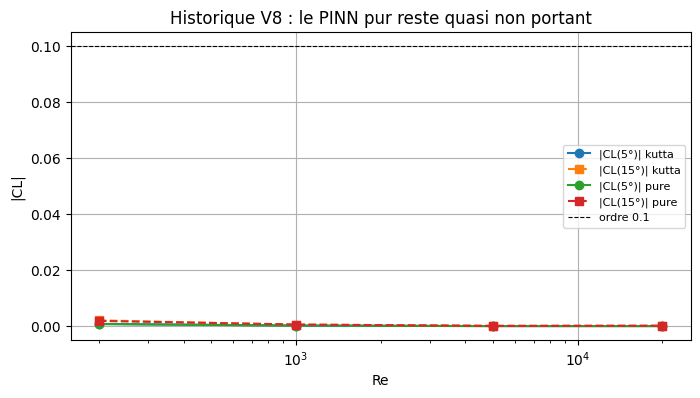

In [3]:

hist_re = lab.historical_re_sweep_table()
display(hist_re)

fig, ax = plt.subplots(figsize=(8, 4))
for variant, g in hist_re.groupby("variant"):
    ax.semilogx(g["Re"], abs(g["CL_5deg"]), marker="o", label=f"|CL(5°)| {variant}")
    ax.semilogx(g["Re"], abs(g["CL_15deg"]), marker="s", linestyle="--", label=f"|CL(15°)| {variant}")
ax.axhline(0.1, color="k", linestyle="--", linewidth=0.8, label="ordre 0.1")
ax.set_xlabel("Re")
ax.set_ylabel("|CL|")
ax.set_title("Historique V8 : le PINN pur reste quasi non portant")
ax.legend(fontsize=8)
plt.show()



## 4. Charger les résultats reproduits

Après exécution de `run_pinn_failure_suite_v2.py`, chaque cas contient :

- `config.json` ;
- `history.csv` ;
- `final_diagnostics.json` ;
- `losses.png` ;
- `CL_history.png` ;
- `surface_Cp.png`.


In [5]:

if OUTDIR.exists():
    summary = lab.summarize_run_directory(OUTDIR)
    display(summary)
else:
    summary = pd.DataFrame()
    print(f"No output directory found: {OUTDIR}")


,case,Re,alpha_deg,fourier,w_kutta,w_data,w_far_cp,CL_pressure,CD_pressure,CM_ref,CL_xfoil,Cp_MAE_vs_XFOIL,final_loss,final_pde,final_wall,time_sec,case_dir
0,01_baseline_Re200,200.0,5.0,False,0.0,0.0,0.0,0.001011,-0.007139,0.000071,NaN,NaN,0.018745,0.003051,0.000200,265.491918,runs_pinn_failure_v2_full\01_baseline_Re200
1,02_farCp_all_boundaries,200.0,5.0,False,0.0,0.0,1.0,0.001041,-0.007072,0.000071,NaN,NaN,0.007882,0.003198,0.000031,265.767193,runs_pinn_failure_v2_full\02_farCp_all_boundaries
2,03_outflowCp_right_top,200.0,5.0,False,0.0,0.0,0.0,0.000743,-0.007096,0.000091,NaN,NaN,0.008247,0.003130,0.000035,265.451179,runs_pinn_failure_v2_full\03_outflowCp_right_top
3,04_fourier_Re200,200.0,5.0,True,0.0,0.0,0.0,0.000812,-0.006462,-0.000329,NaN,NaN,0.016625,0.003656,0.000011,436.271109,runs_pinn_failure_v2_full\04_fourier_Re200
4,05_kutta_Re200,200.0,5.0,False,2.0,0.0,0.0,0.000570,-0.007044,0.000125,NaN,NaN,0.012726,0.002987,0.000118,271.666145,runs_pinn_failure_v2_full\05_kutta_Re200
5,10_Re1000_pure,1000.0,5.0,False,0.0,0.0,0.0,0.000324,-0.001401,0.000011,NaN,NaN,0.036798,0.002379,0.000581,259.037658,runs_pinn_failure_v2_full\10_Re1000_pure
6,10_Re20000_pure,20000.0,5.0,False,0.0,0.0,0.0,0.000452,0.000151,-0.000031,NaN,NaN,0.007488,0.002315,0.000043,263.689849,runs_pinn_failure_v2_full\10_Re20000_pure
7,10_Re200_pure,200.0,5.0,False,0.0,0.0,0.0,0.000701,-0.007153,0.000113,NaN,NaN,0.008127,0.003044,0.000041,266.937809,runs_pinn_failure_v2_full\10_Re200_pure
8,10_Re5000_pure,5000.0,5.0,False,0.0,0.0,0.0,-0.002716,-0.000354,0.000239,NaN,NaN,0.009191,0.002324,0.000032,265.306218,runs_pinn_failure_v2_full\10_Re5000_pure
9,11_Re1000_kutta,1000.0,5.0,False,2.0,0.0,0.0,0.000210,-0.001498,0.000031,NaN,NaN,0.008243,0.002338,0.000032,273.346070,runs_pinn_failure_v2_full\11_Re1000_kutta


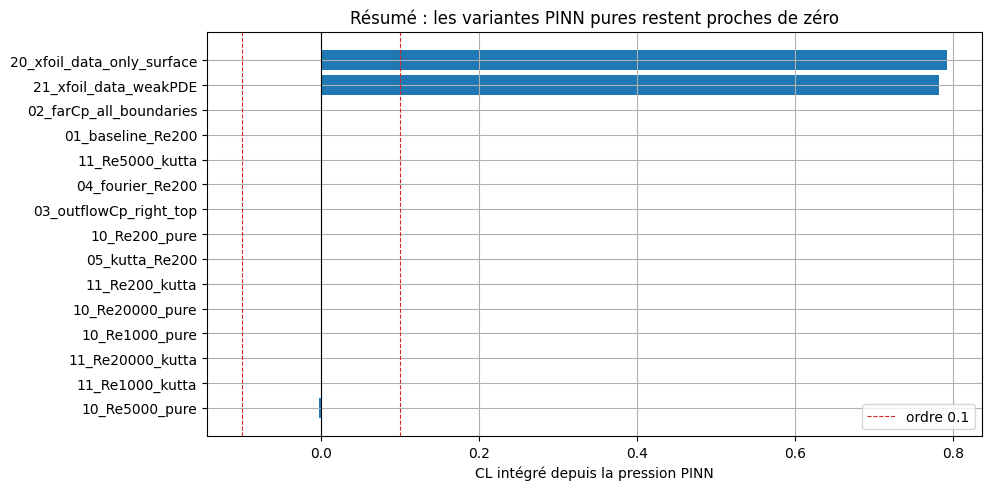

In [6]:

if len(summary):
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(summary))))
    d = summary.dropna(subset=["CL_pressure"]).copy()
    d = d.sort_values("CL_pressure")
    ax.barh(d["case"], d["CL_pressure"].astype(float))
    ax.axvline(0, color="k", linewidth=0.8)
    ax.axvline(0.1, color="tab:red", linestyle="--", linewidth=0.8, label="ordre 0.1")
    ax.axvline(-0.1, color="tab:red", linestyle="--", linewidth=0.8)
    ax.set_xlabel("CL intégré depuis la pression PINN")
    ax.set_title("Résumé : les variantes PINN pures restent proches de zéro")
    ax.legend()
    plt.show()



## 5. Visualiser les cas un par un

La cellule suivante affiche automatiquement les figures sauvegardées pour chaque cas. C'est souvent la manière la plus claire de montrer que :

- les pertes peuvent diminuer ;
- les conditions aux limites peuvent être raisonnablement satisfaites ;
- mais la pression de surface reste presque symétrique ;
- donc \(C_L\) reste très faible.


# Experiment Guide – PINN Airfoil Failure Suite

This notebook reproduces the different approaches explored during the project to obtain a physically meaningful aerodynamic solution around a NACA 2412 airfoil using PINNs.

The experiments are grouped by families.

---

# 01 — Baseline PINN (`01_baseline_Re200`)

## Goal
Train a standard PINN on the incompressible steady Navier–Stokes equations around the airfoil.

## Setup
- Reynolds number: `Re = 200`
- PDE residuals only
- Standard boundary conditions
- No Kutta condition
- No data supervision

## Expected observation
The network converges numerically, but the pressure field remains nearly symmetric.

Typical result:
- very weak lift
- `CL ≈ 0`
- no realistic circulation

This is the reference failure case.

---

# 02 — Far-field pressure everywhere (`02_farCp_all_boundaries`)

## Goal
Test whether the issue comes from badly constrained pressure.

## Modification
A pressure condition is imposed on all external boundaries.

## Motivation
The baseline PINN may drift because pressure is only defined up to a constant.

We tested whether stronger pressure anchoring would help the network create circulation.

## Expected observation
The solution becomes more stable numerically, but the flow still remains almost non-lifting.

The network tends toward a symmetric low-energy solution.

---

# 03 — Pressure only on outlet/top (`03_outflowCp_right_top`)

## Goal
Use more physically plausible pressure conditions.

## Modification
Pressure is constrained only on:
- outlet boundary
- upper boundary

instead of all boundaries.

## Motivation
Imposing pressure everywhere may over-constrain the flow.

This setup attempts to imitate a more realistic outflow condition.

## Expected observation
Slightly different pressure distributions, but still no strong lift generation.

---

# 04 — Fourier Features (`04_fourier_Re200`)

## Goal
Test whether the PINN lacks high-frequency spatial representation capacity.

## Modification
Fourier feature encoding is added to the network input.

## Motivation
PINNs are known to suffer from spectral bias:
they preferentially learn smooth low-frequency solutions.

The wake and boundary layer structures may require higher-frequency representations.

## Expected observation
Sharper local structures may appear, but the global circulation problem remains unresolved.

Lift remains small.

---

# 05 — Kutta Condition (`05_kutta_Re200`)

## Goal
Force the network toward a physically lifting solution.

## Modification
A Kutta-like penalty is added near the trailing edge.

## Motivation
A lifting airfoil requires circulation.
The Kutta condition is what selects the physical circulation solution in classical aerodynamics.

Without it, the PINN tends to converge toward a nearly symmetric solution.

## Expected observation
Some increase in asymmetry and lift may appear, but the effect remains limited.

The solution still does not reproduce realistic XFOIL-like pressure distributions.

---

# 10 / 11 — Reynolds Sweep

These experiments test whether the main issue comes from the Reynolds number.

---

## `10_ReXXX_pure`

### Goal
Run the baseline PINN at several Reynolds numbers.

### Tested values
- `Re = 200`
- `Re = 1000`
- `Re = 5000`
- `Re = 20000`

### Motivation
Very low Reynolds numbers produce highly diffusive flows.

We tested whether increasing Reynolds number would naturally allow circulation to emerge.

### Expected observation
The pressure field changes somewhat, but the PINN still converges toward weakly lifting solutions.

---

## `11_ReXXX_kutta`

### Goal
Combine higher Reynolds numbers with the Kutta condition.

### Modification
Same Reynolds sweep as above, but with the Kutta penalty enabled.

### Motivation
Maybe the failure was caused jointly by:
- low Reynolds number
- lack of circulation selection

### Expected observation
Lift increases somewhat compared to pure runs, but the solutions remain far from realistic aerodynamic pressure distributions.

---

# 20 — XFOIL Surface Data Only (`20_xfoil_data_only_surface`)

## Goal
Test whether the network can reproduce realistic pressure fields when supervised directly with data.

## Modification
Surface pressure coefficients `Cp` from XFOIL are used as supervision.

No PDE residual is used.

## Motivation
This experiment answers an important question:

> Is the network architecture itself incapable of representing lifting solutions?

If the network can fit XFOIL data correctly, then the problem comes from the PINN formulation rather than the neural network itself.

## Expected observation
The network reproduces realistic pressure distributions and non-zero lift.

This demonstrates that the architecture is capable of representing physically meaningful aerodynamic solutions.

---

# 21 — XFOIL Data + Weak PDE (`21_xfoil_data_weakPDE`)

## Goal
Combine supervised pressure data with weak physics regularization.

## Modification
- XFOIL surface `Cp` supervision
- weak PDE residual term

## Motivation
This experiment tests a hybrid approach:
physics-informed supervised learning.

Instead of relying purely on PDE constraints, the network is guided toward realistic aerodynamic states.

## Expected observation
Stable lifting solutions with realistic pressure distributions.

This configuration was significantly more successful than the pure PINN approaches.

---

# Main Conclusion

The experiments strongly suggest that:

1. Standard PINNs converge easily toward nearly symmetric non-lifting solutions.
2. Adding Kutta penalties alone is insufficient.
3. Increasing Reynolds number alone is insufficient.
4. The neural network architecture itself is capable of representing lifting flows.
5. Adding physically realistic supervision (XFOIL pressure distributions) drastically improves the solution quality.

The main limitation therefore appears to come from the optimization landscape and constraints of the pure PINN formulation rather than from the representational capacity of the neural network itself.


01_baseline_Re200


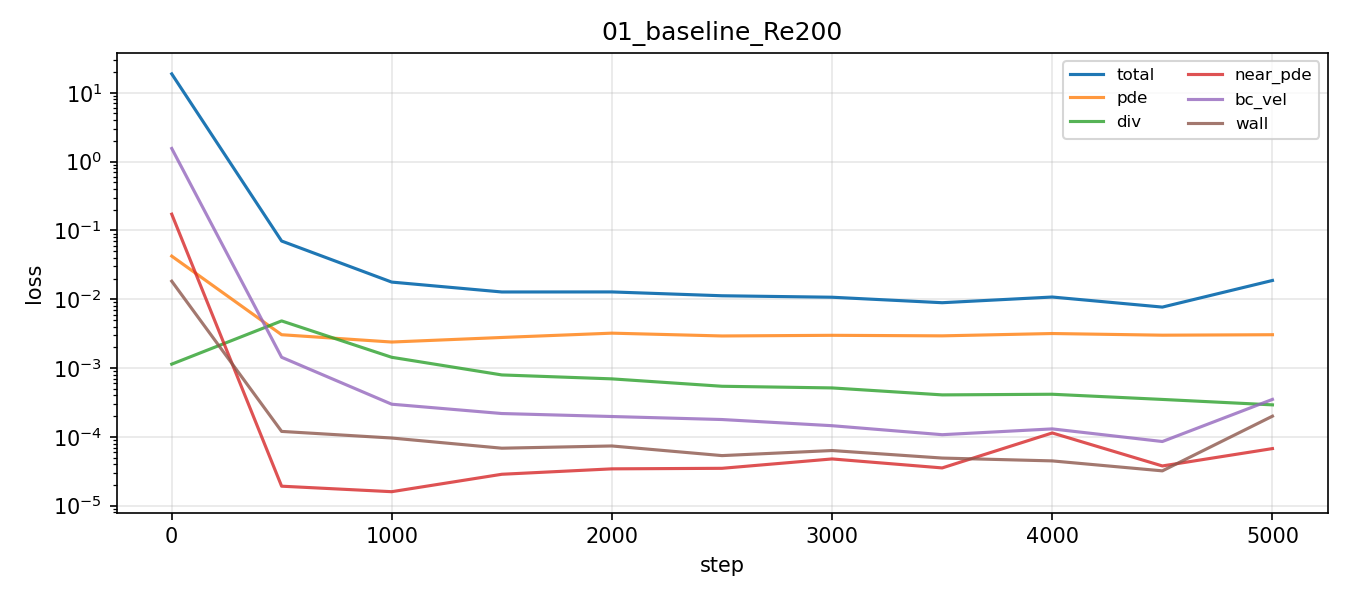

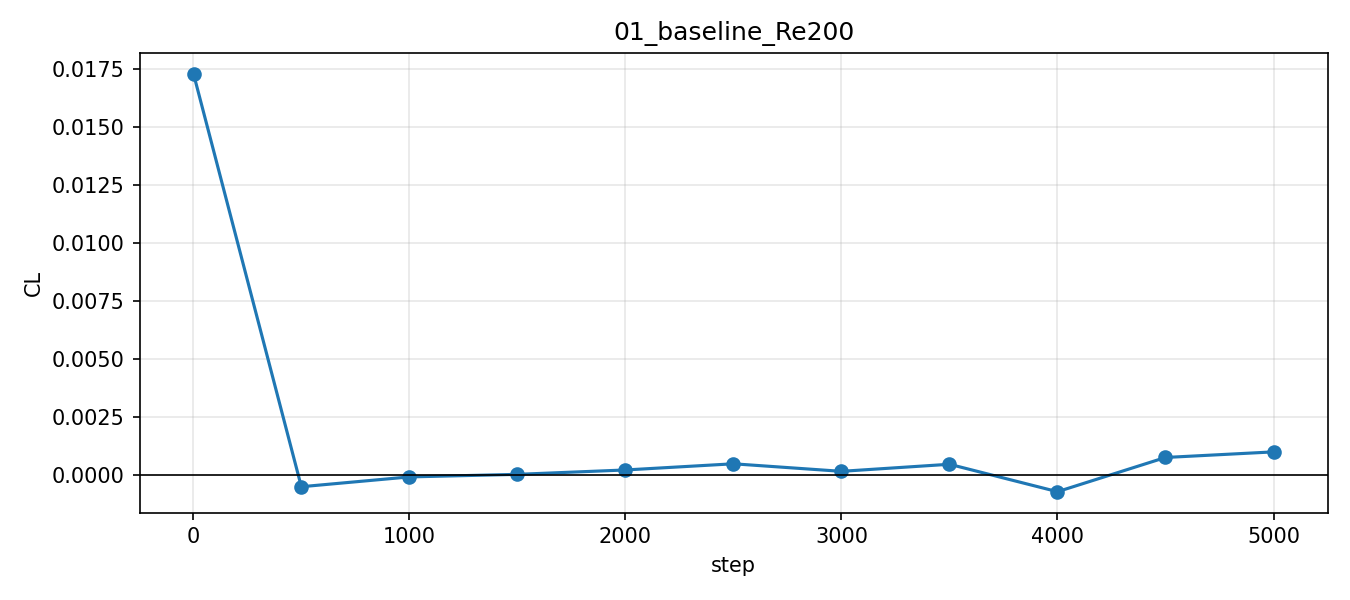

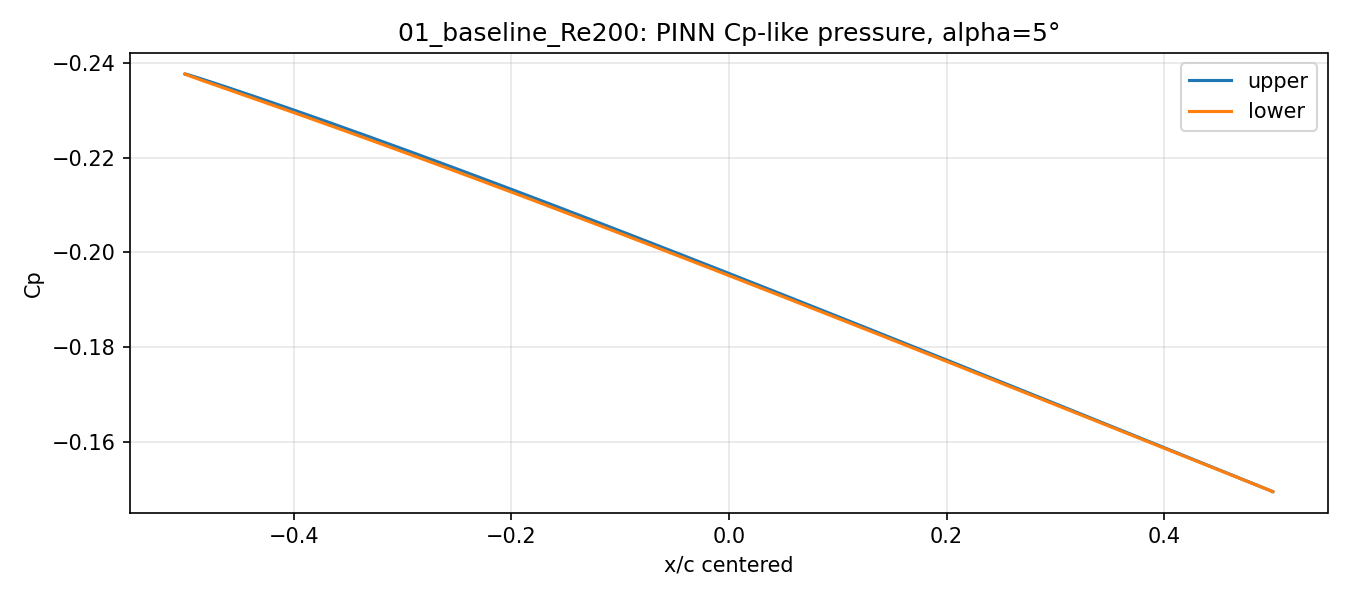


02_farCp_all_boundaries


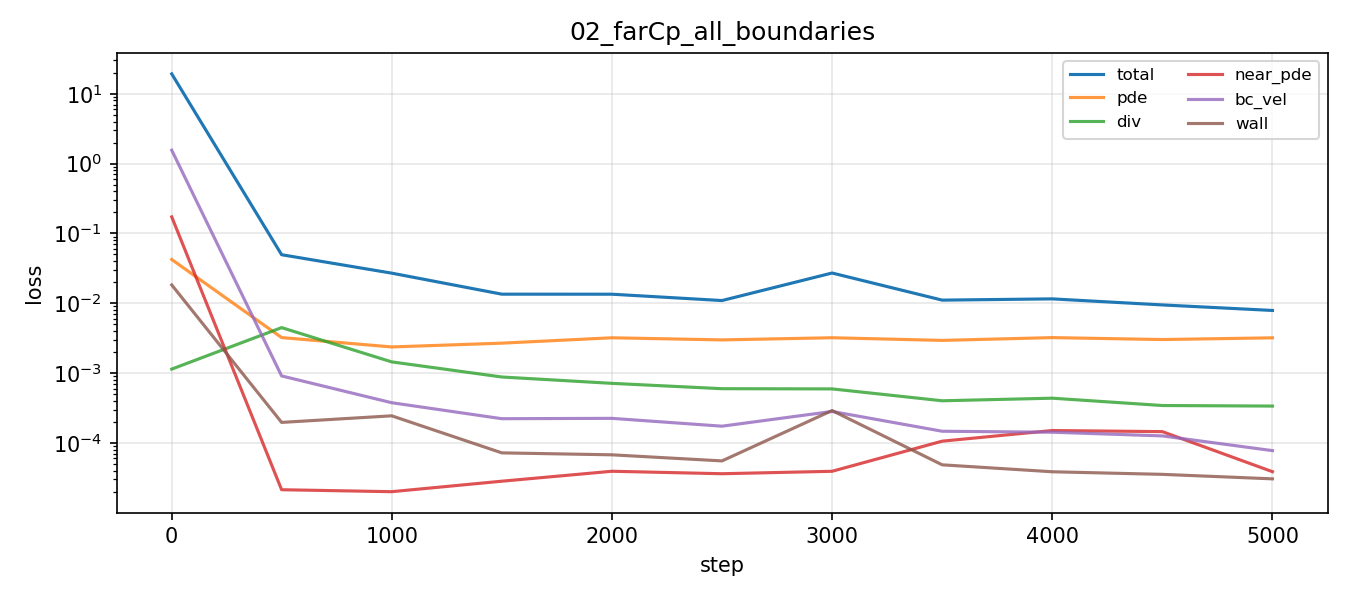

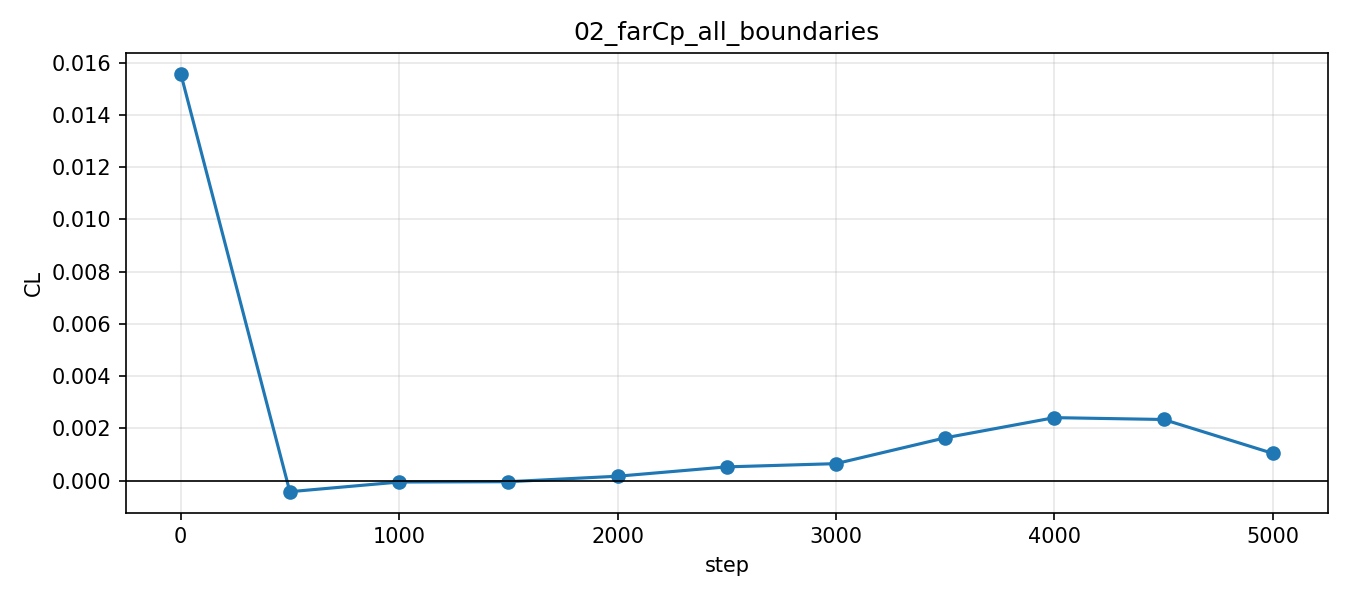

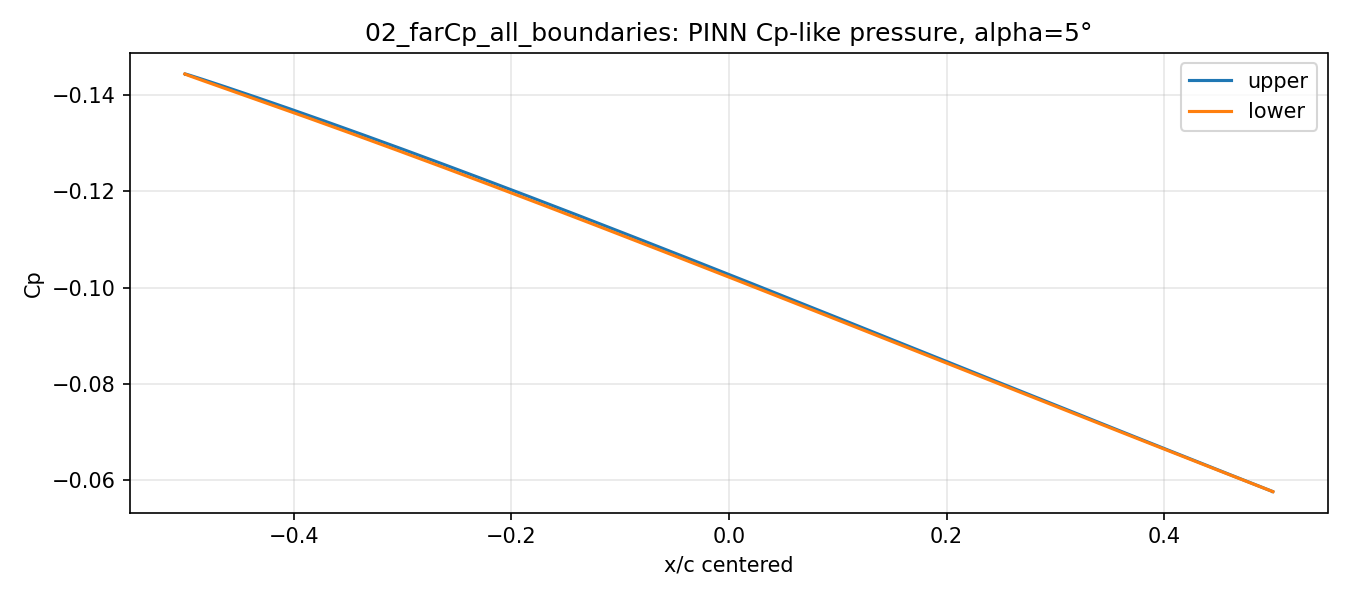


03_outflowCp_right_top


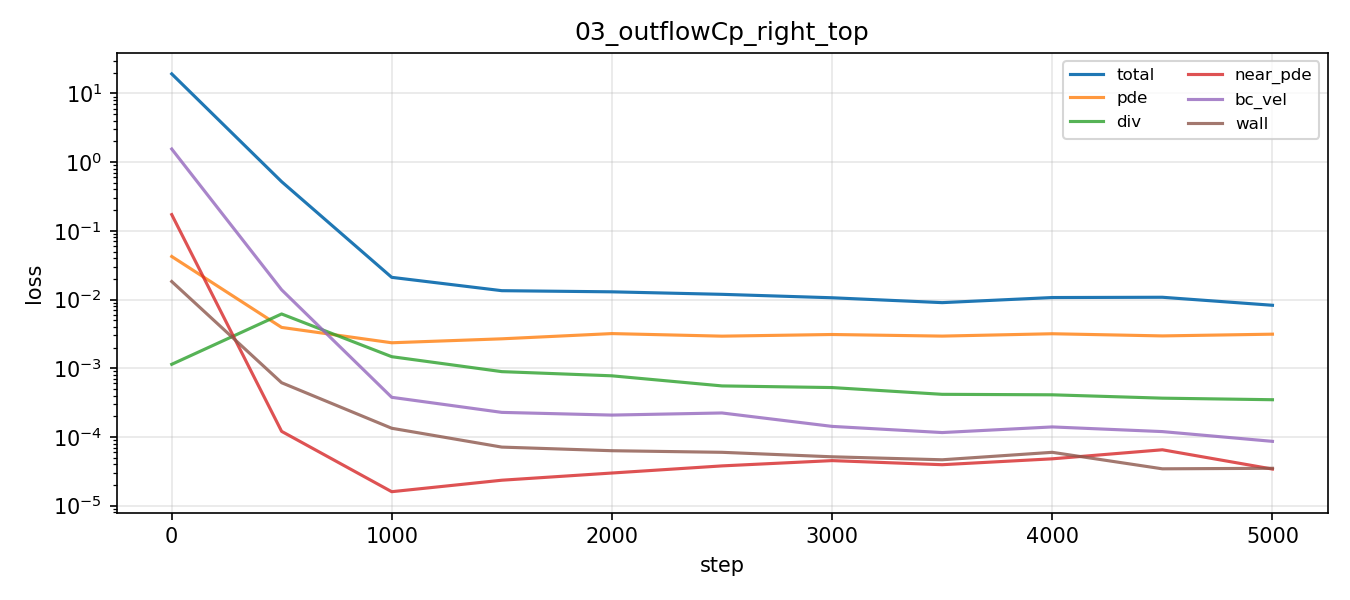

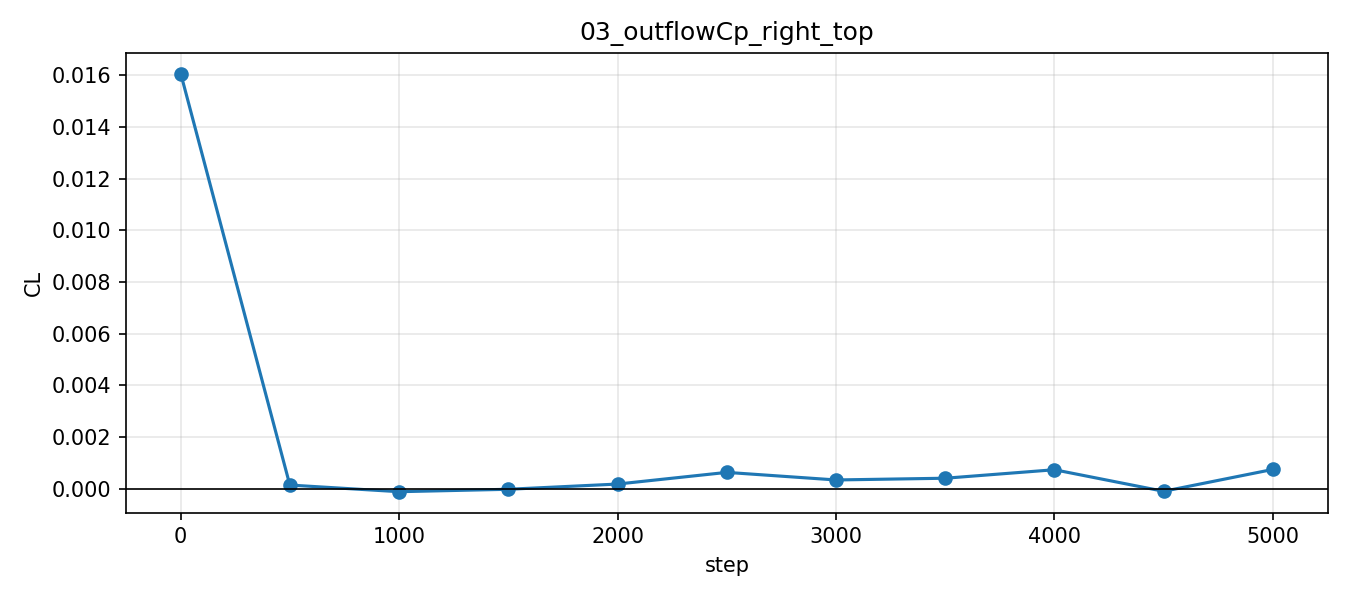

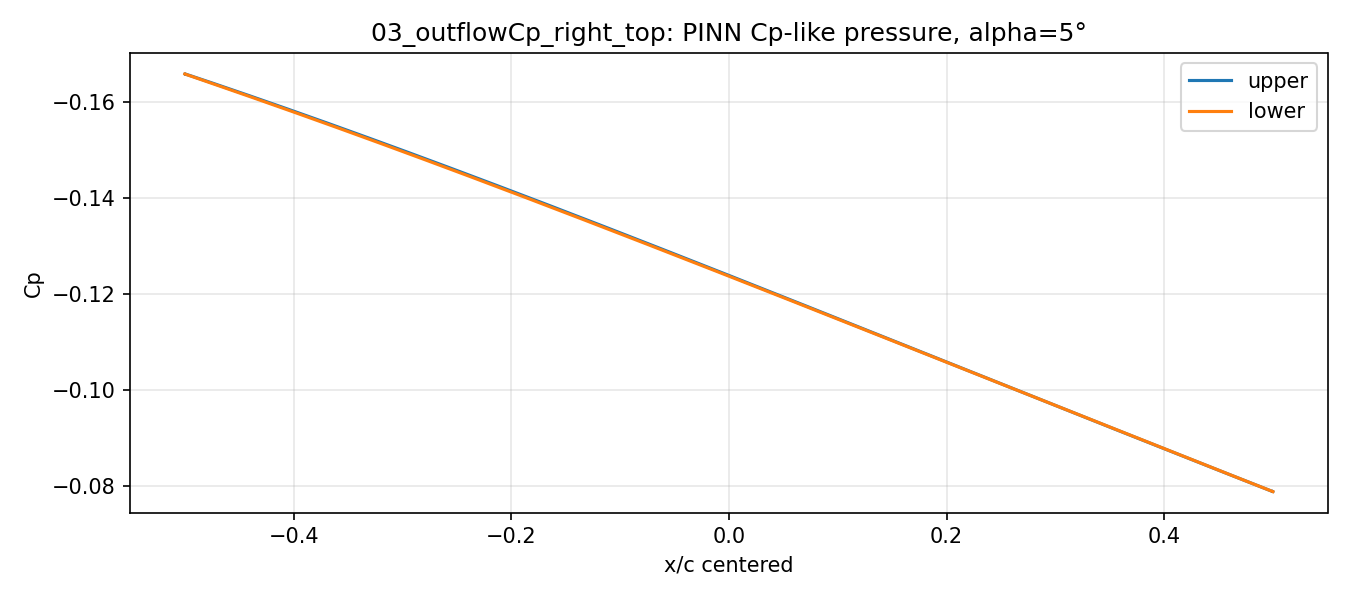


04_fourier_Re200


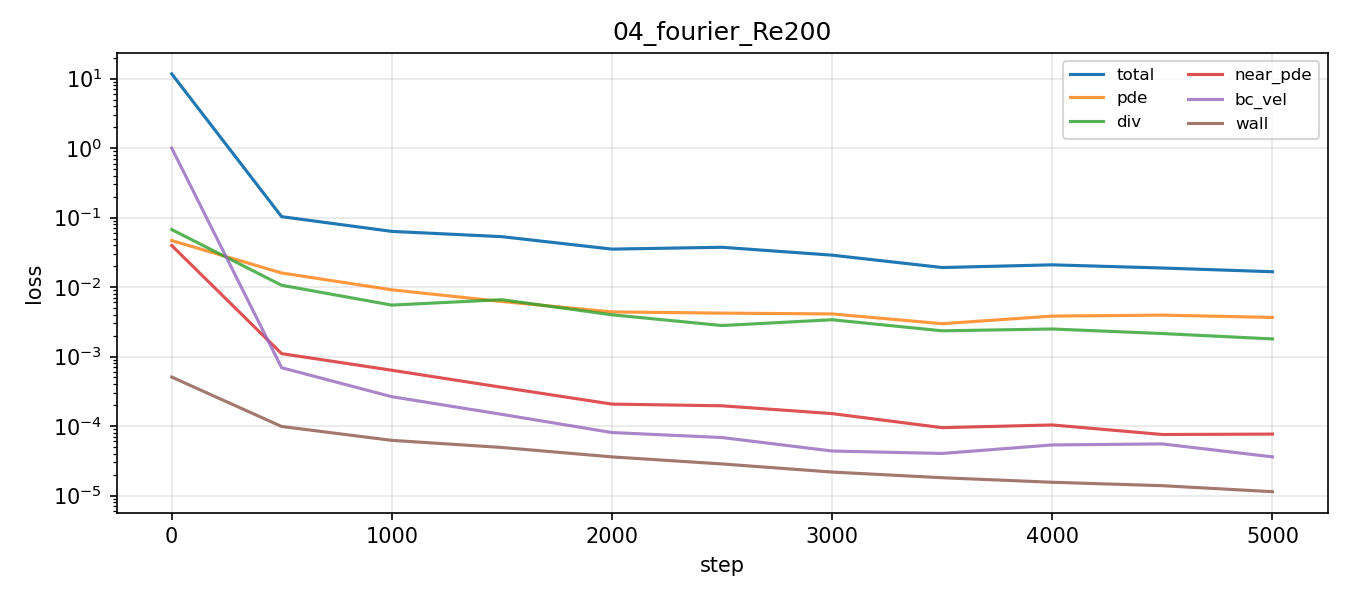

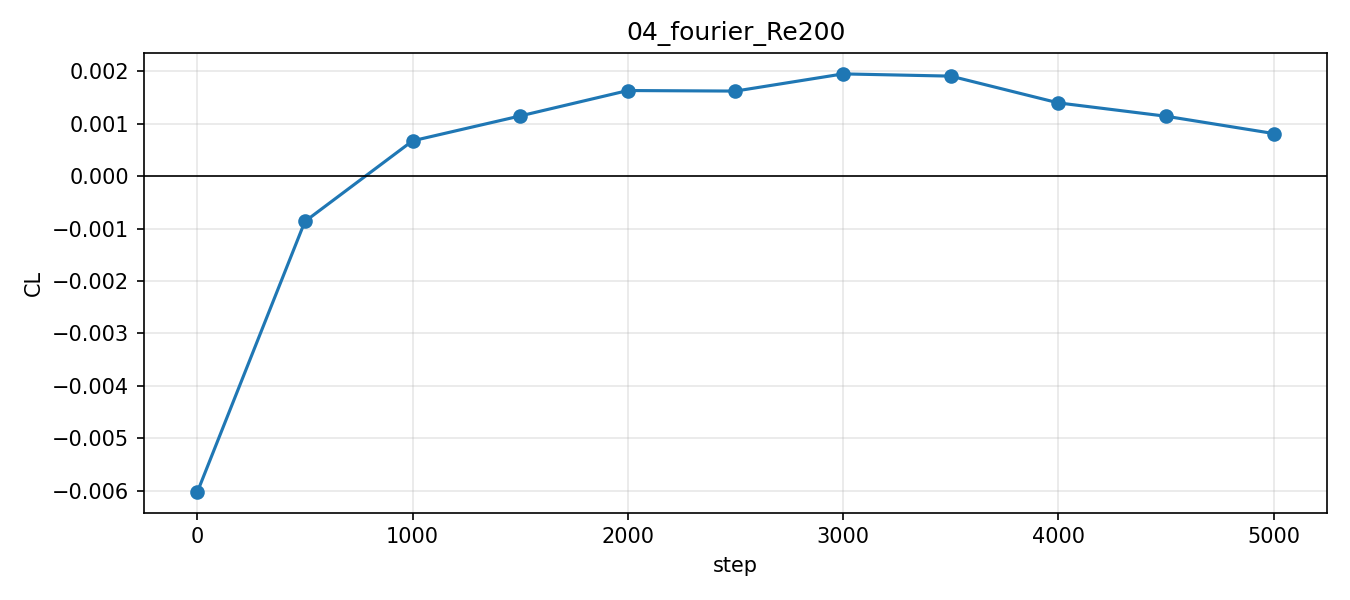

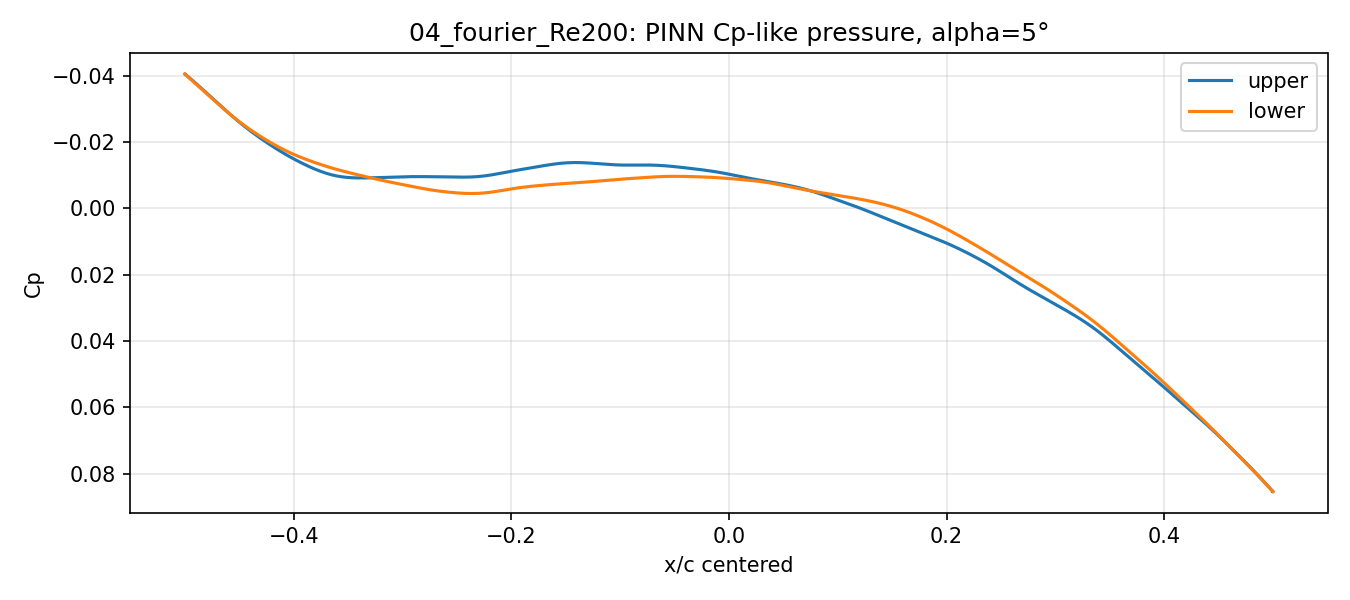


05_kutta_Re200


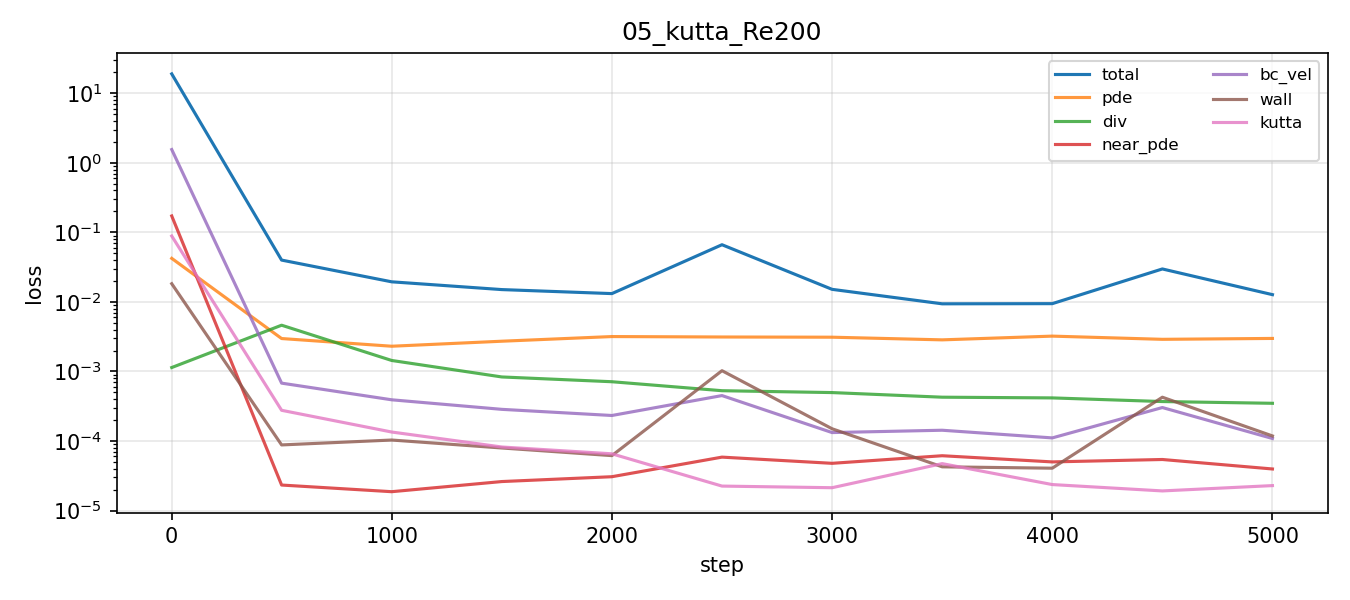

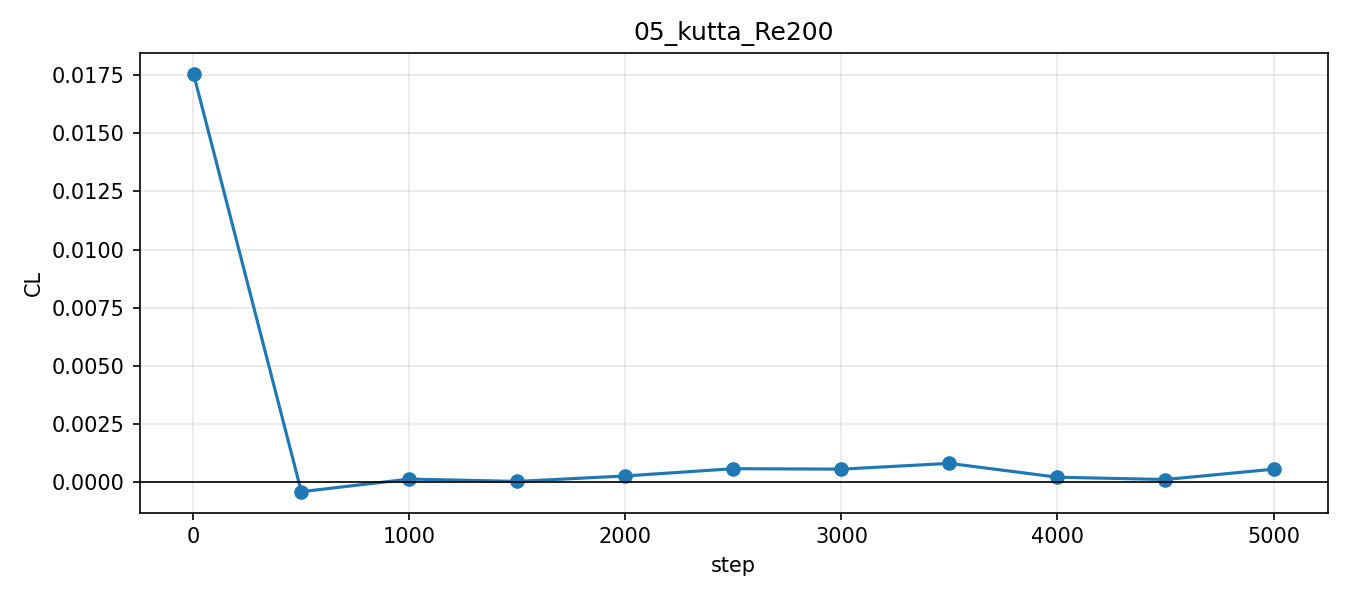

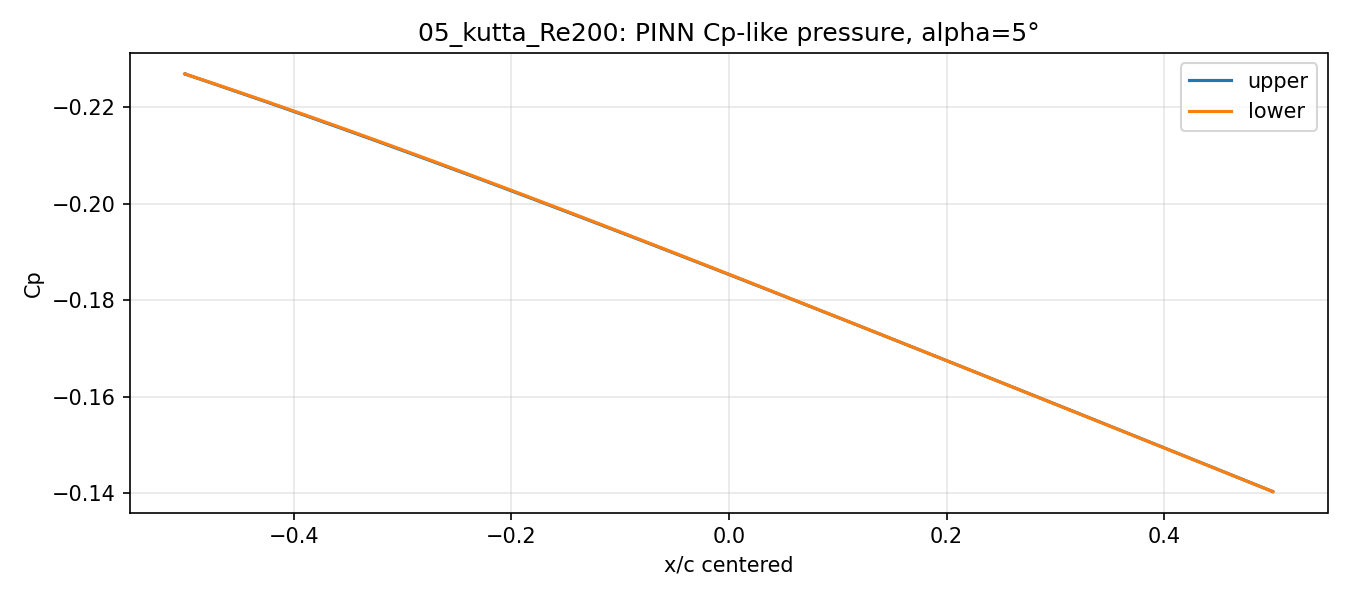


10_Re1000_pure


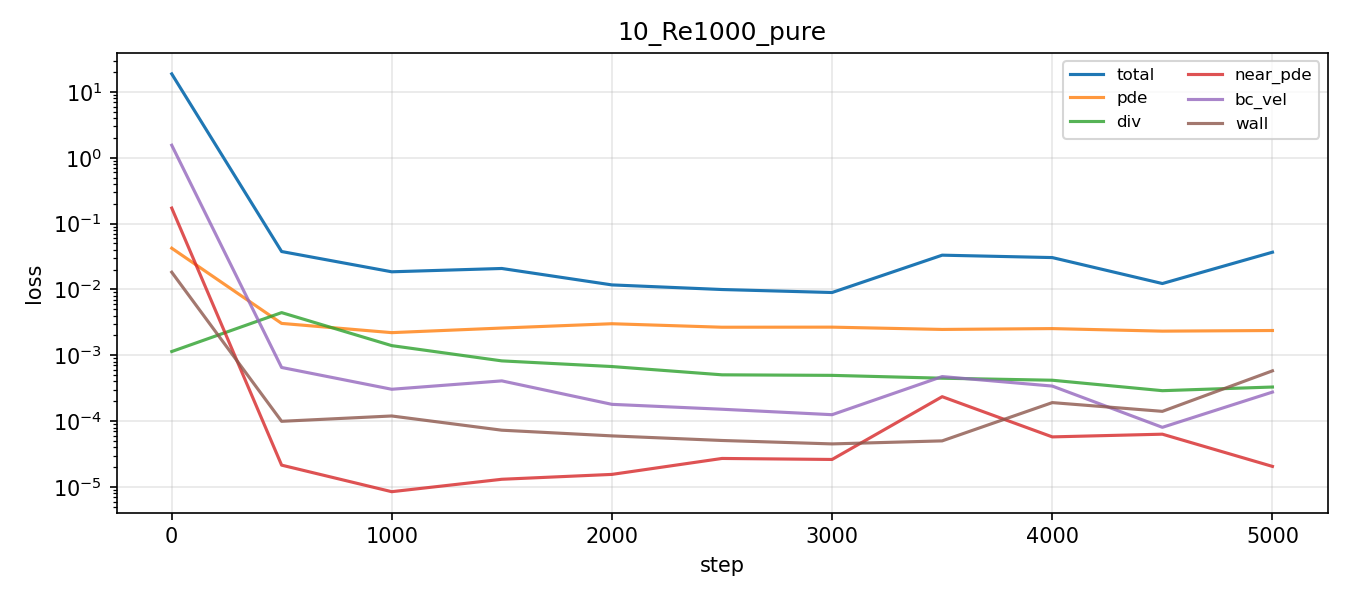

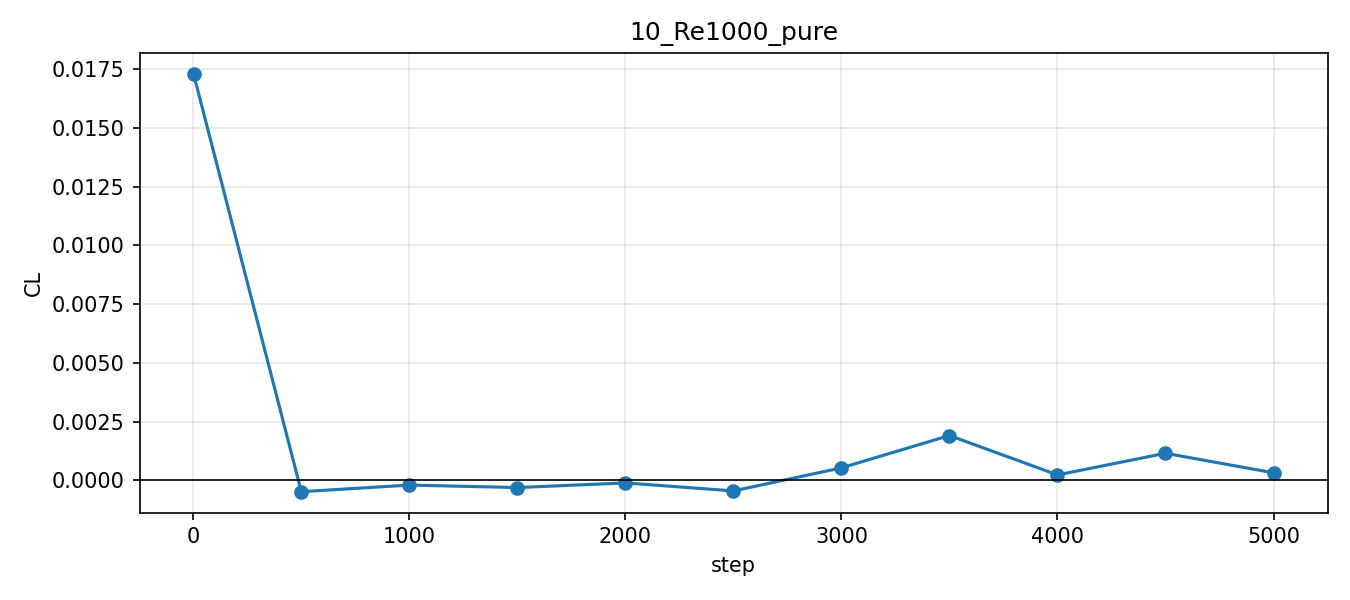

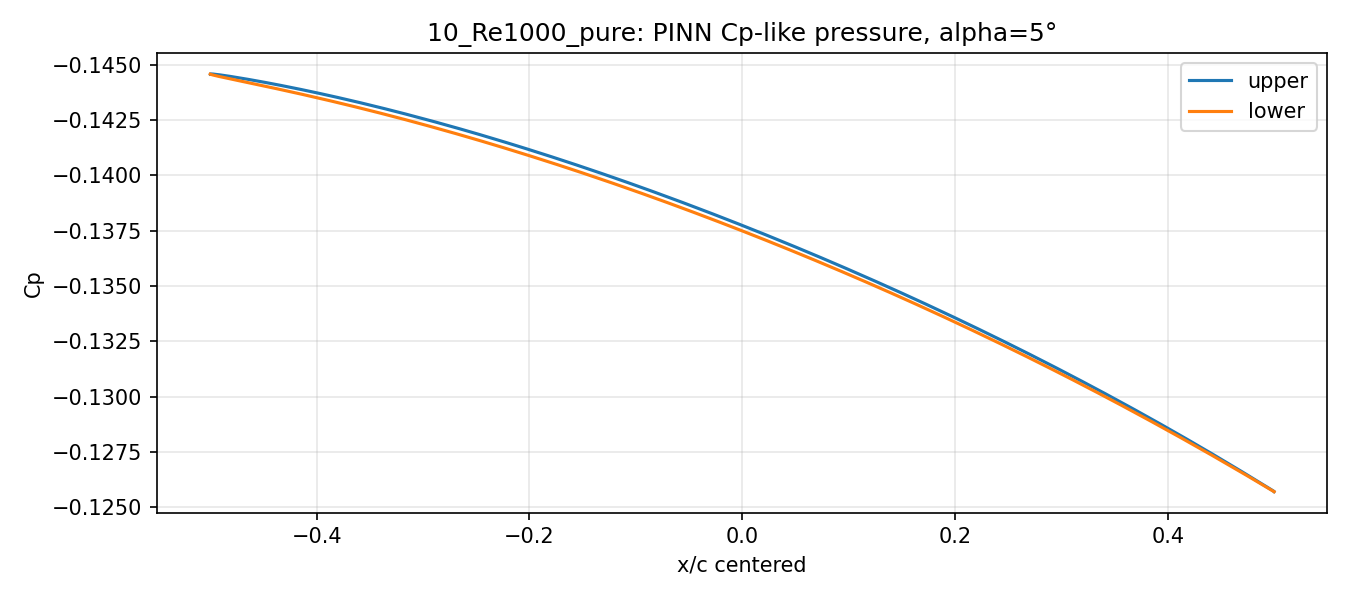


10_Re20000_pure


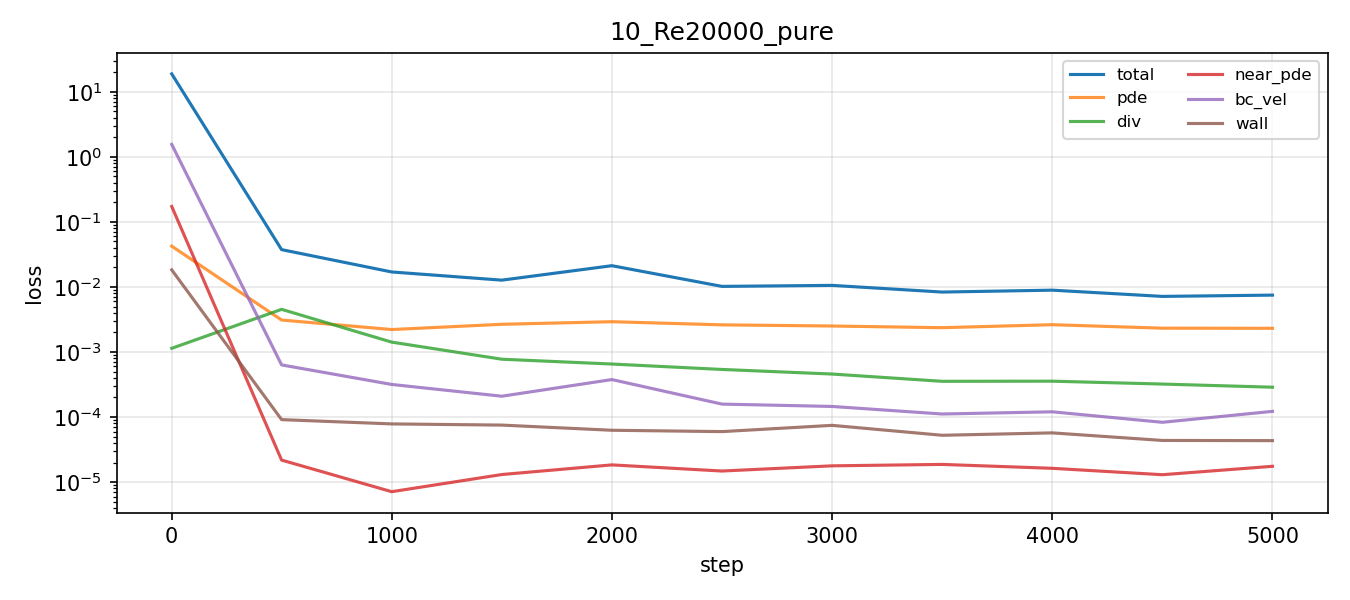

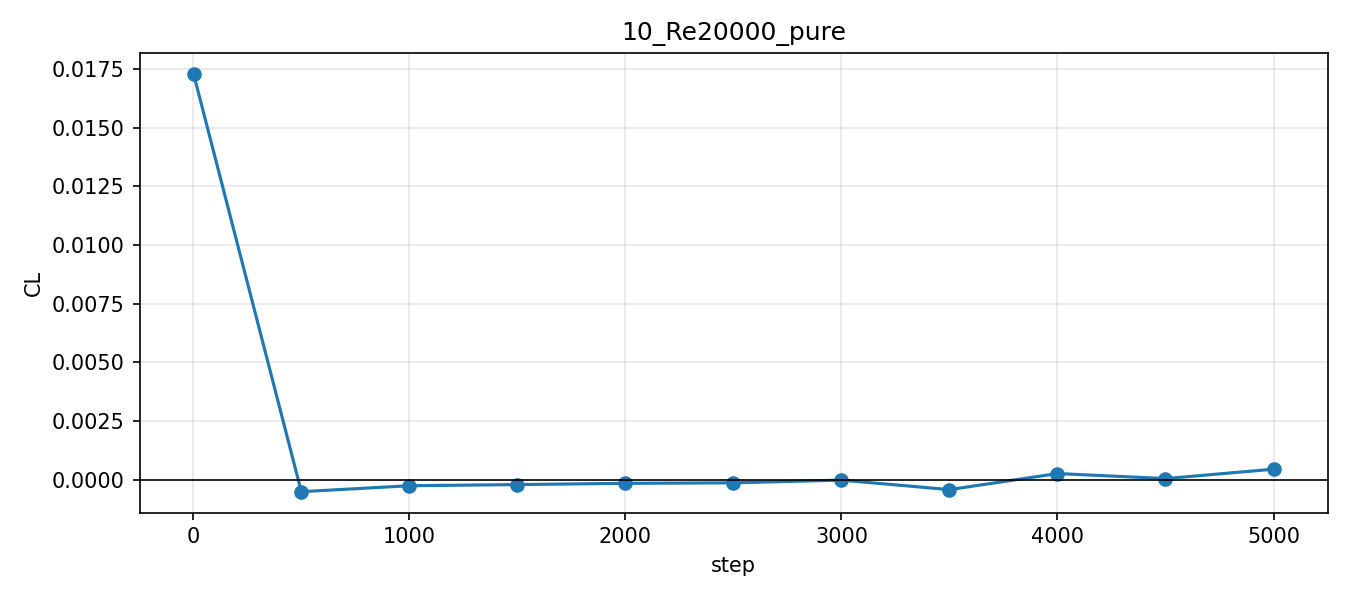

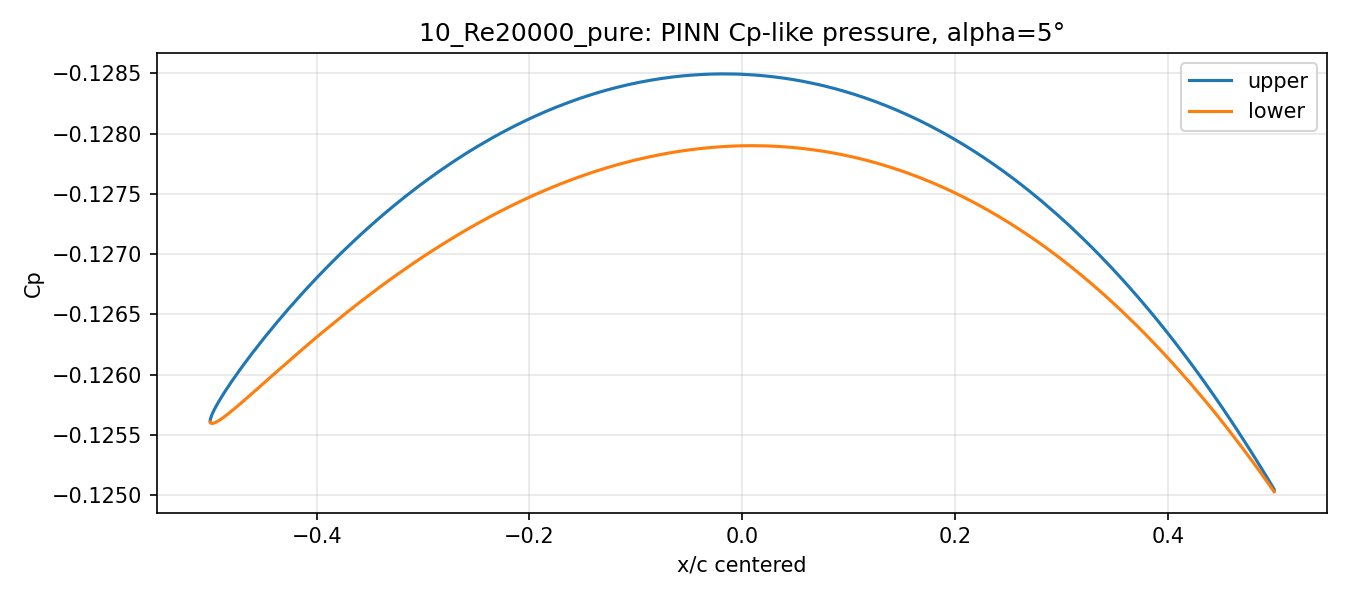


10_Re200_pure


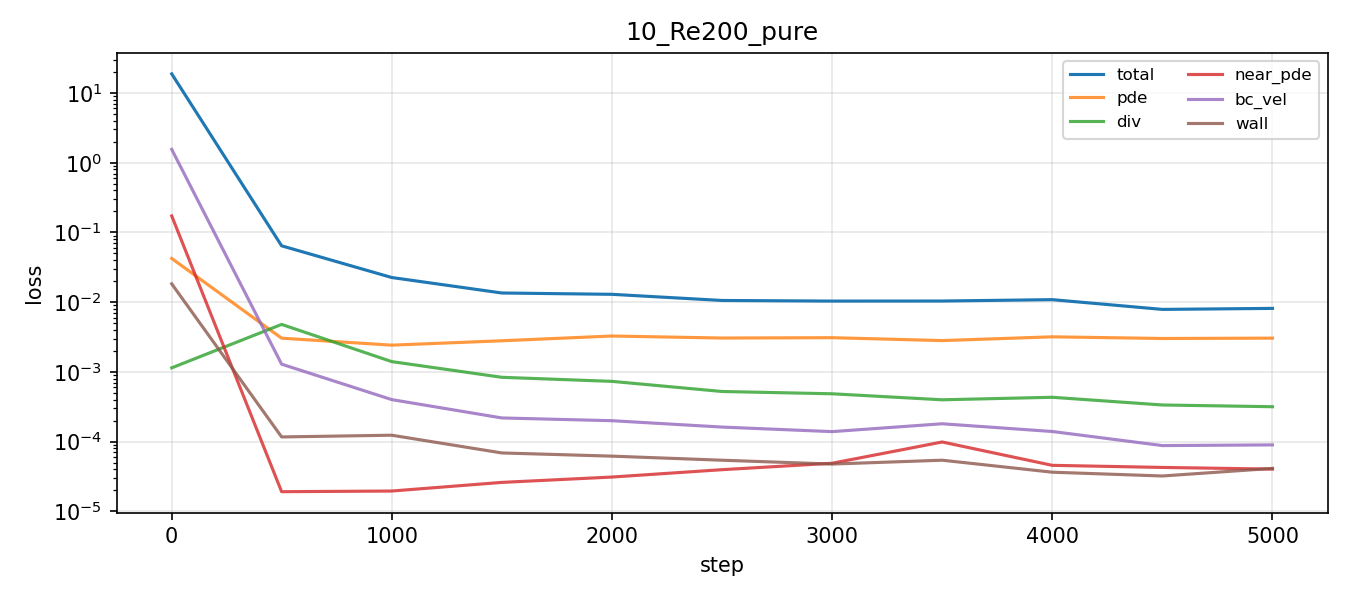

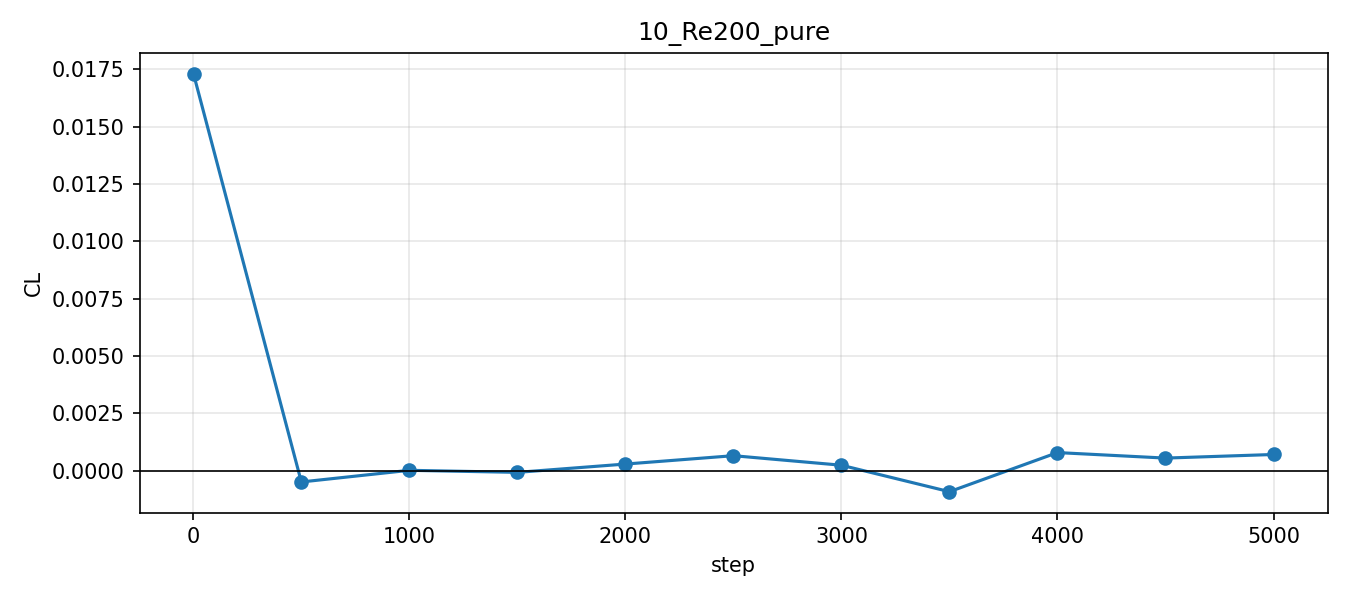

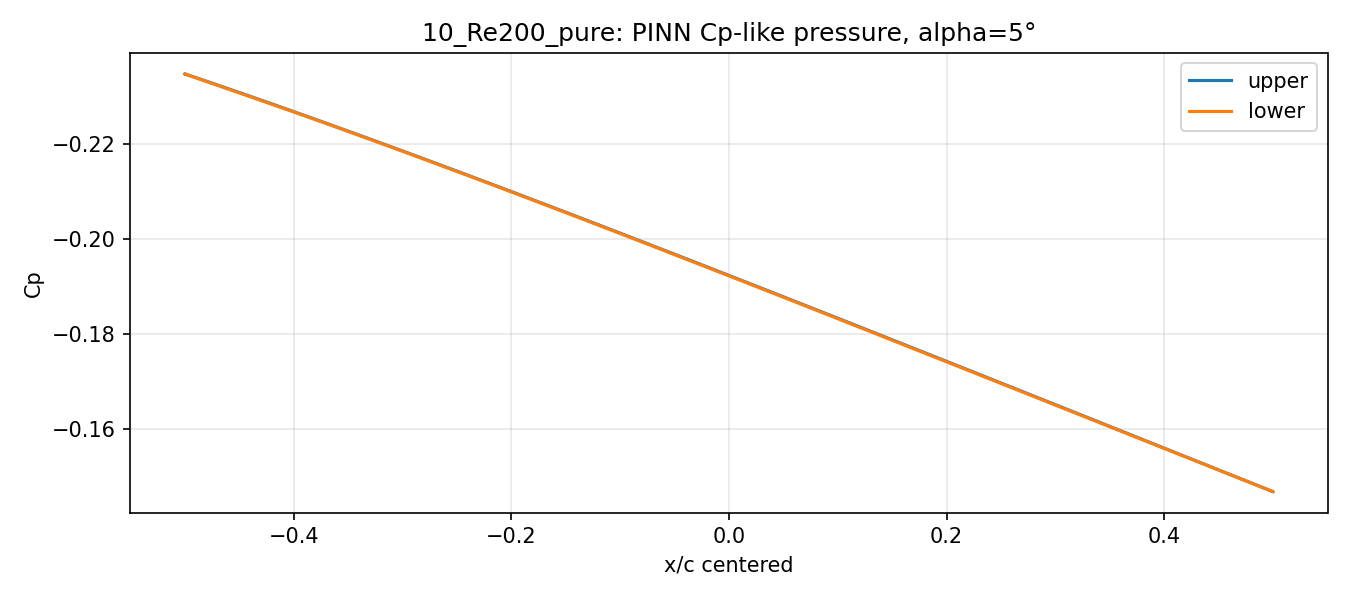


10_Re5000_pure


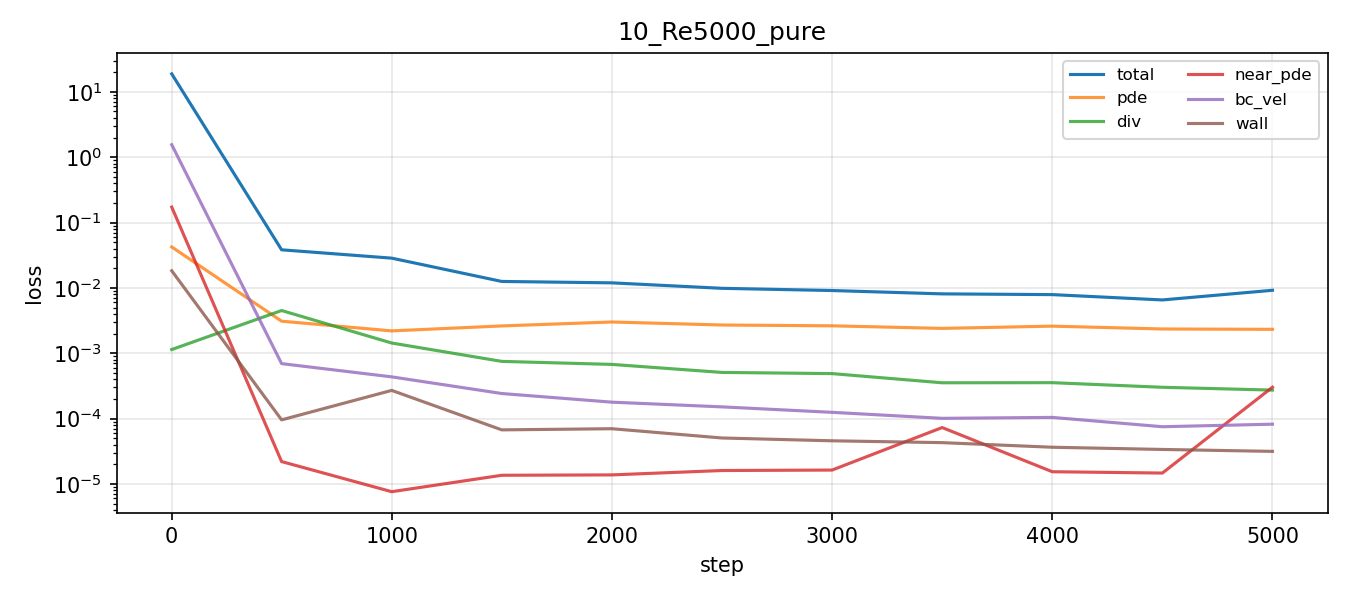

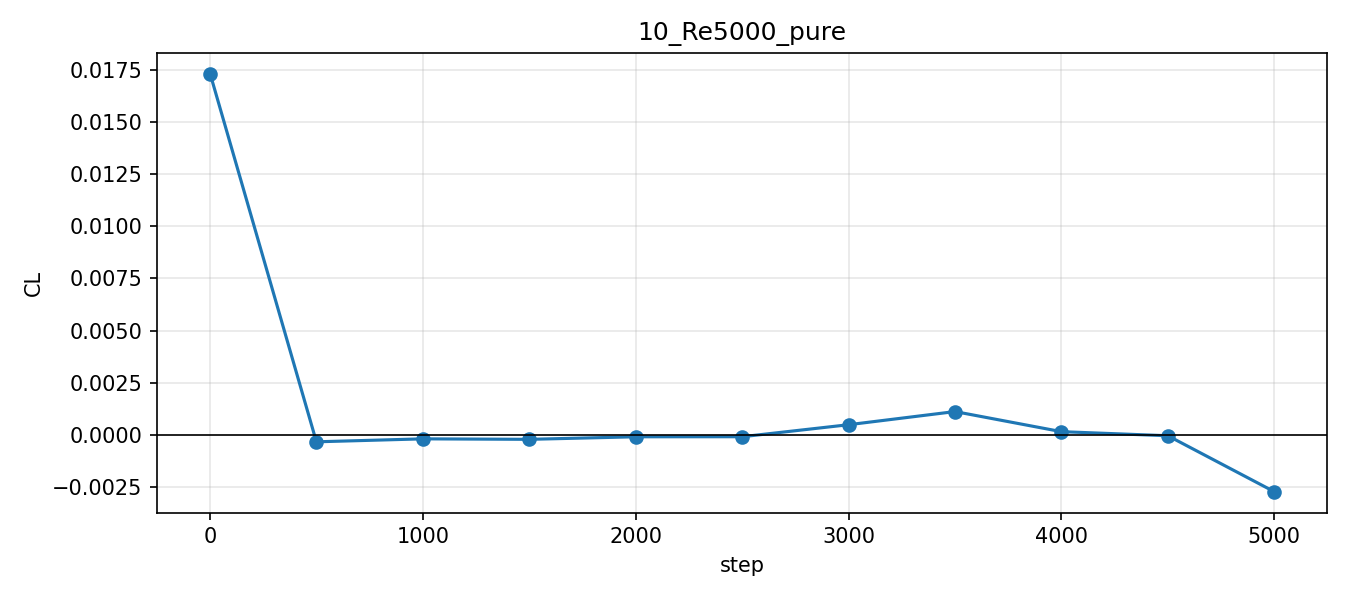

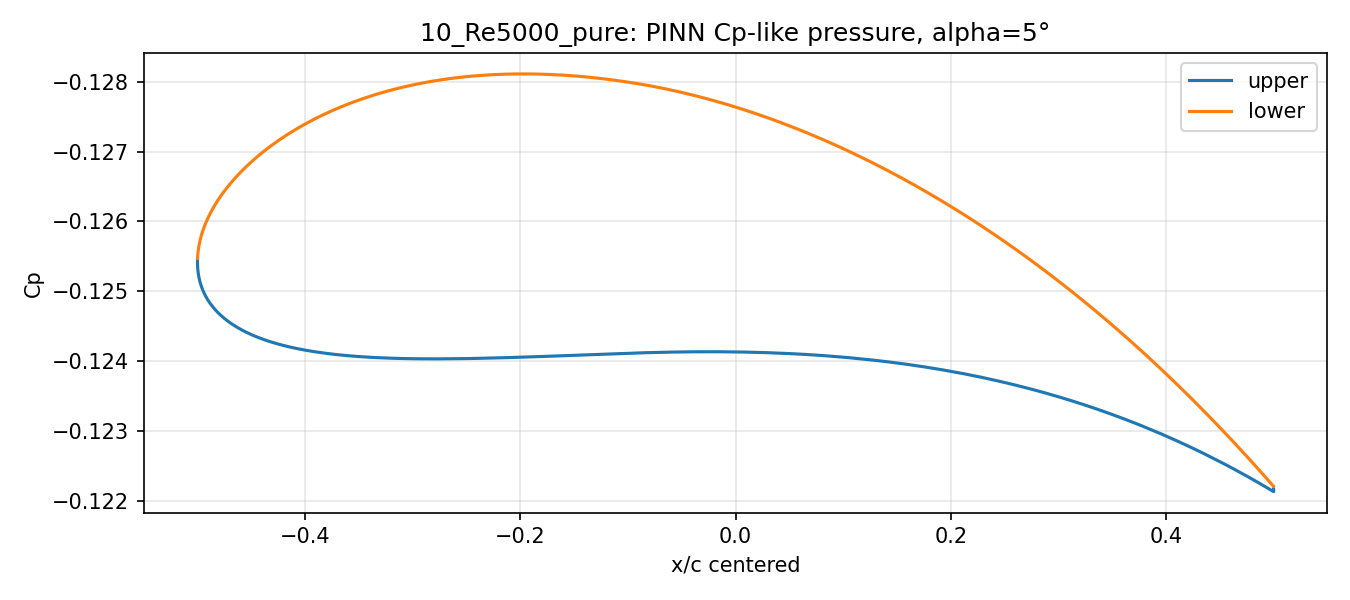


11_Re1000_kutta


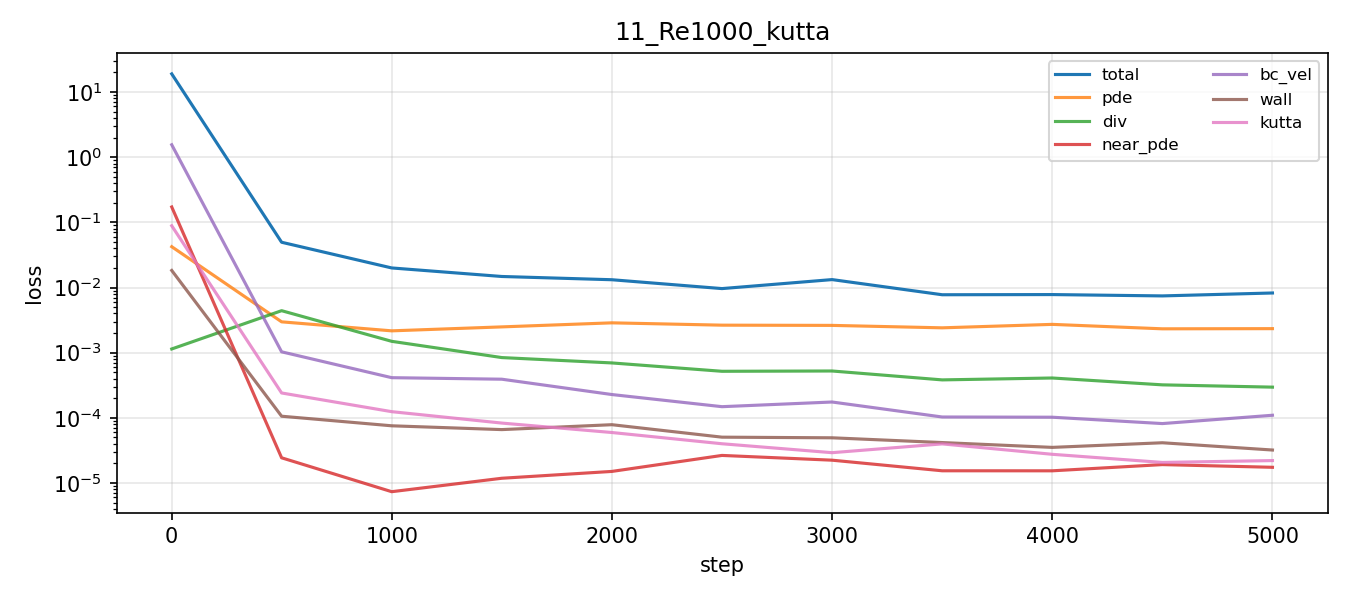

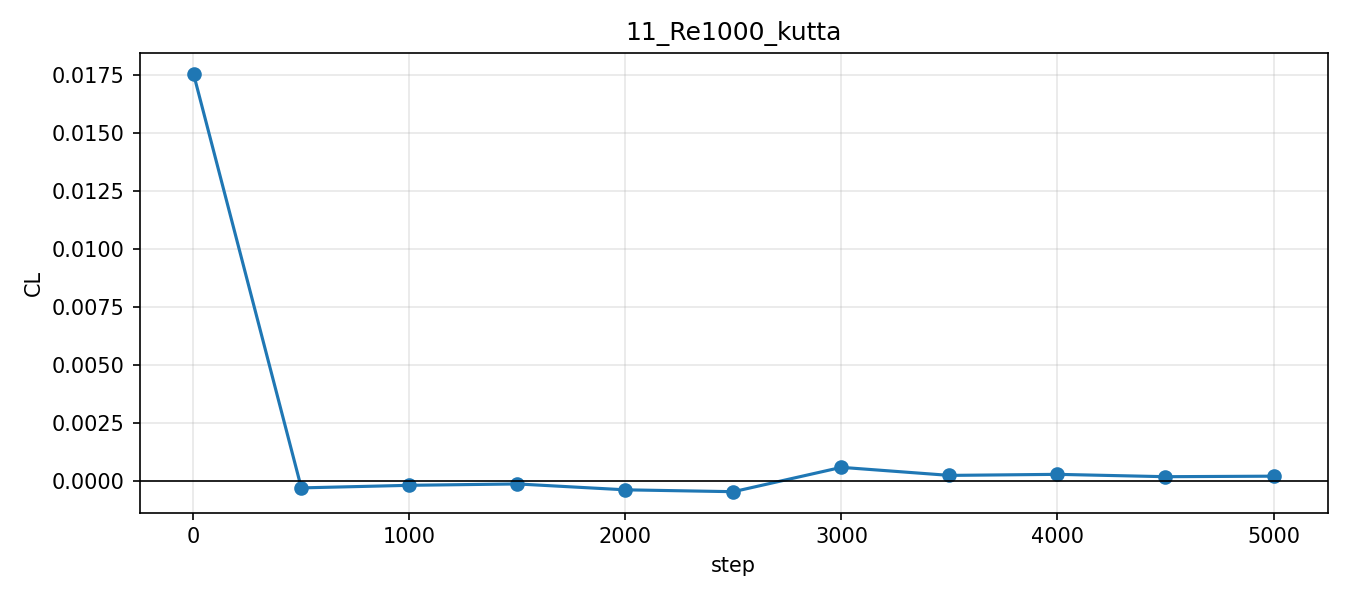

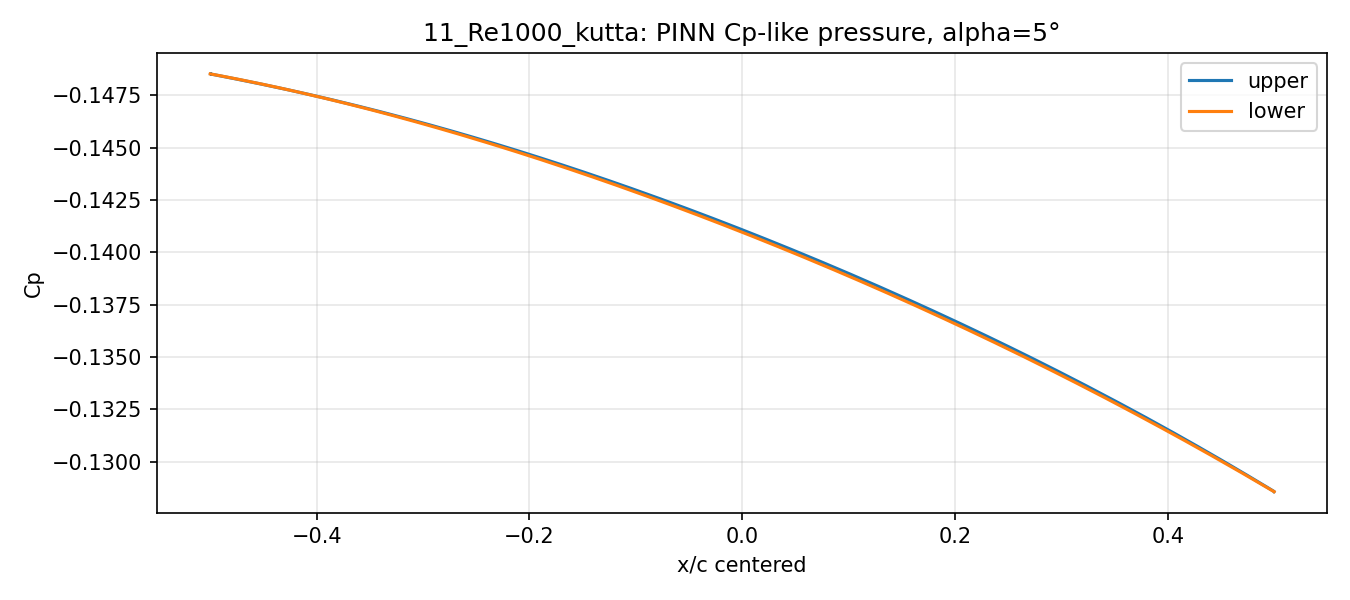


11_Re20000_kutta


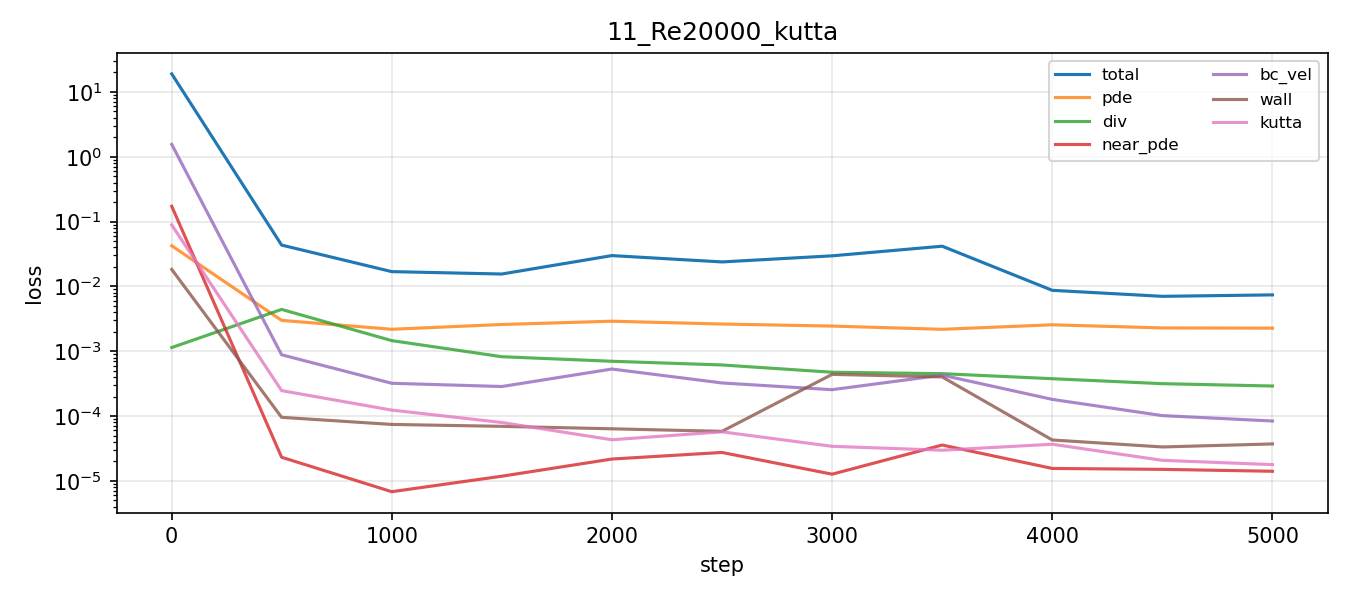

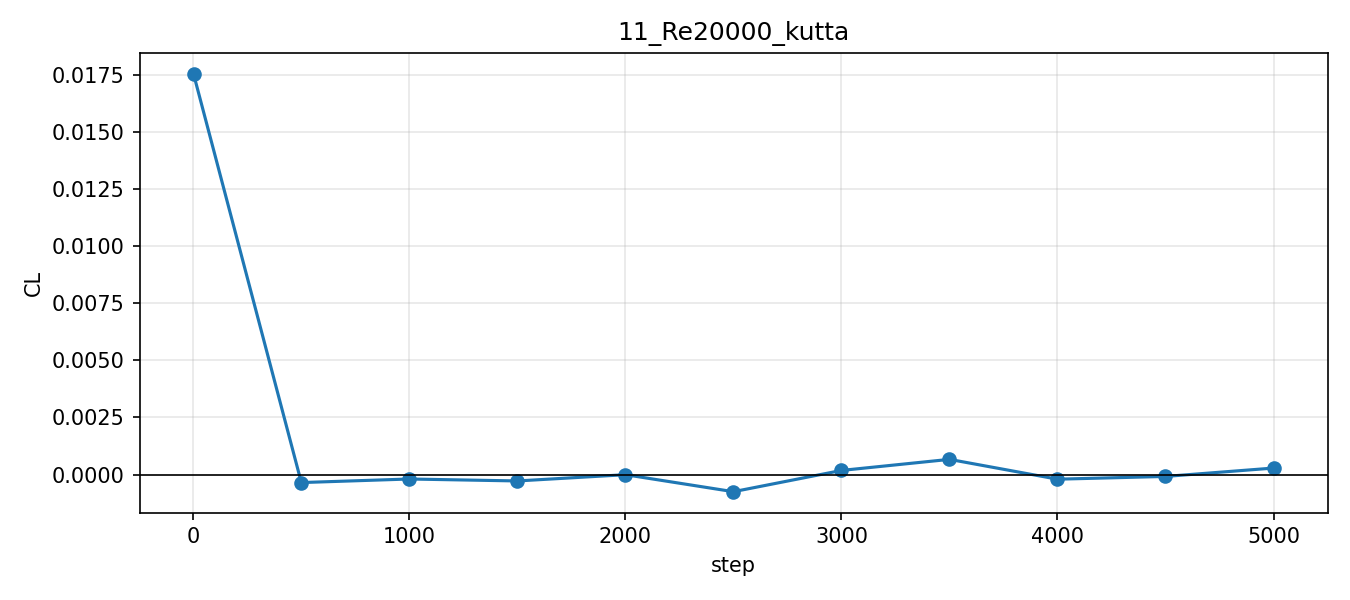

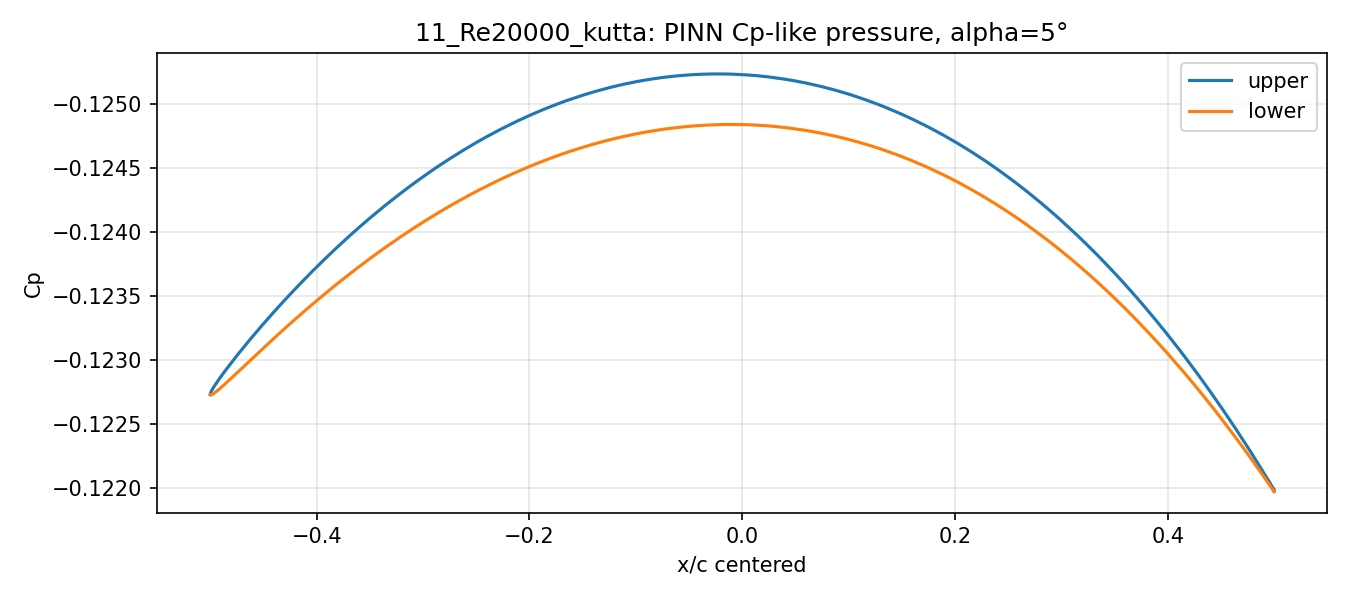


11_Re200_kutta


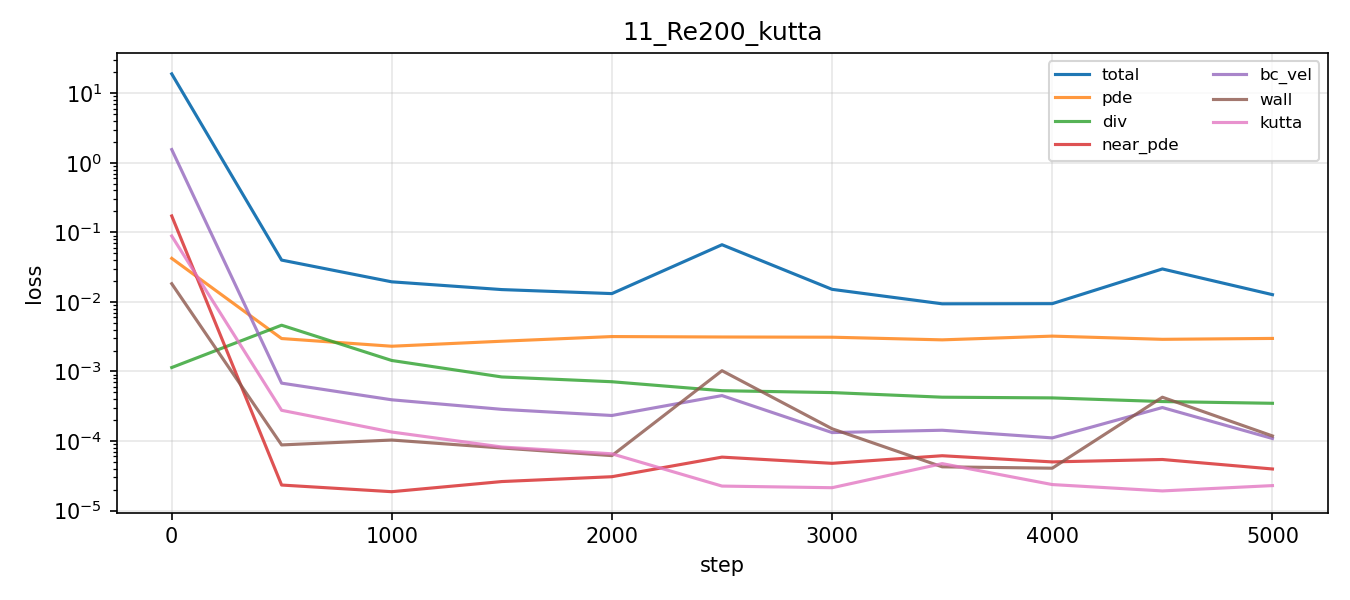

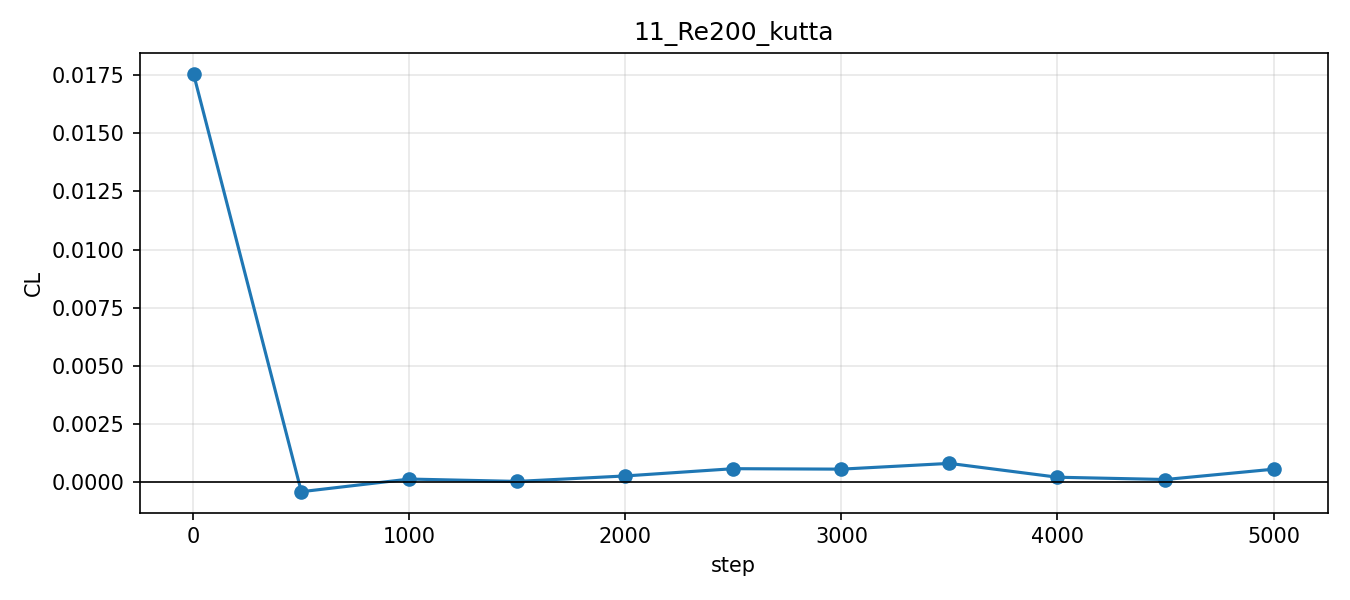

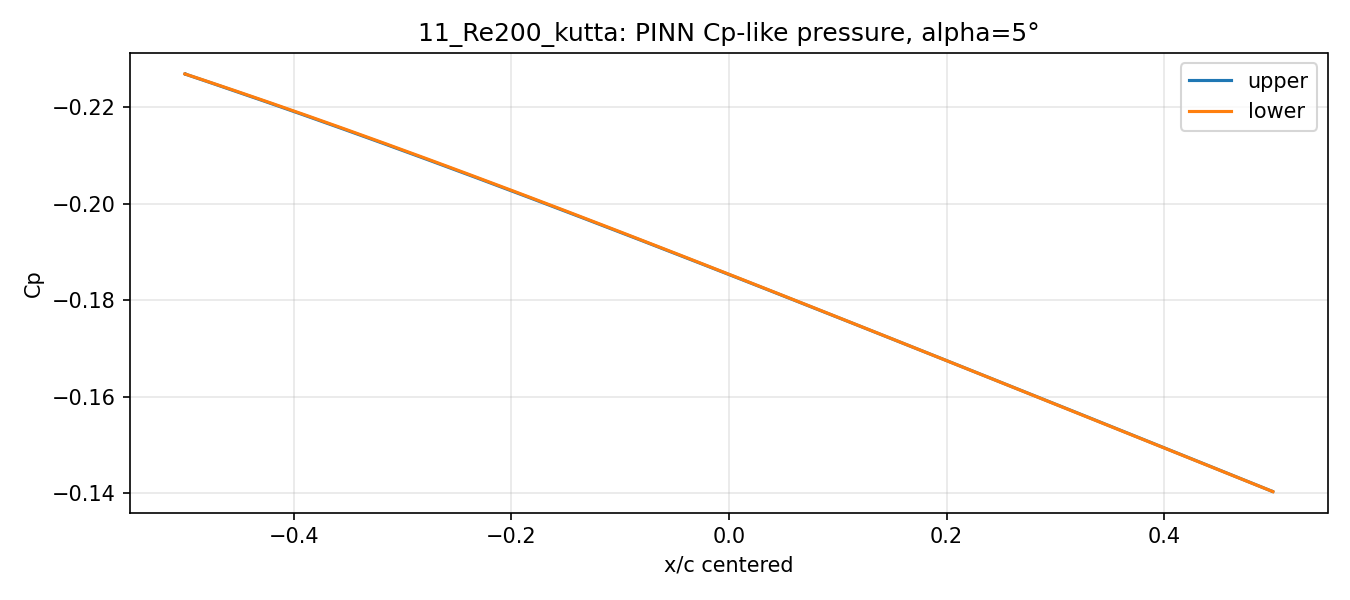


11_Re5000_kutta


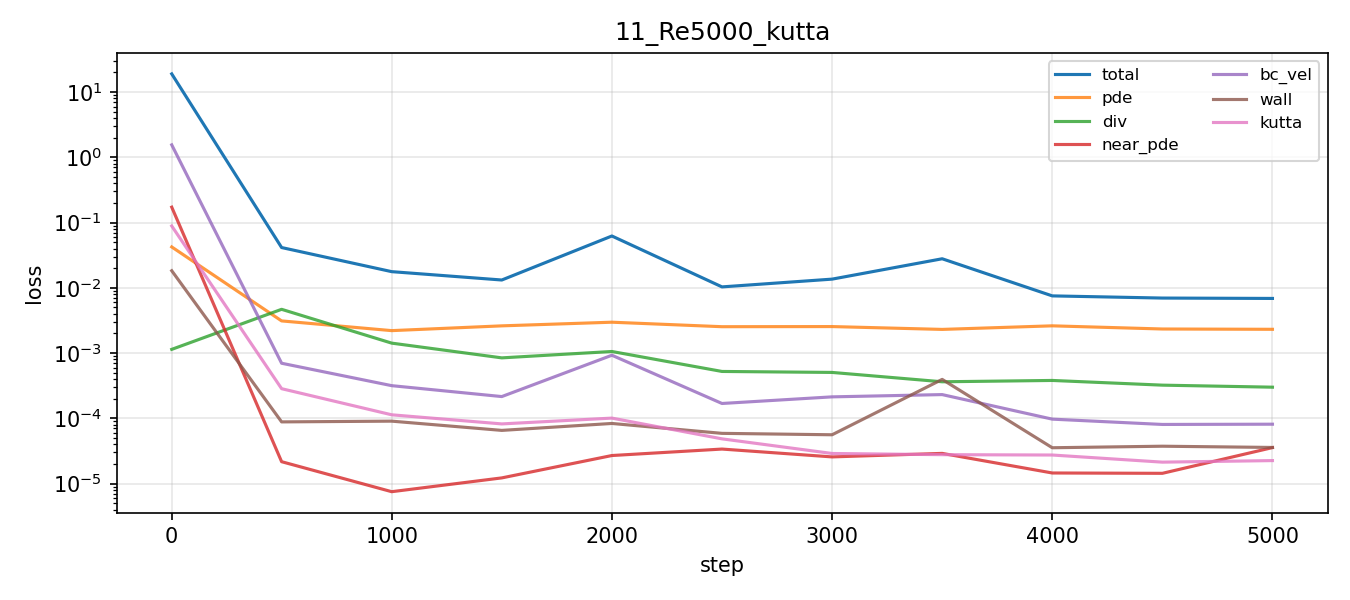

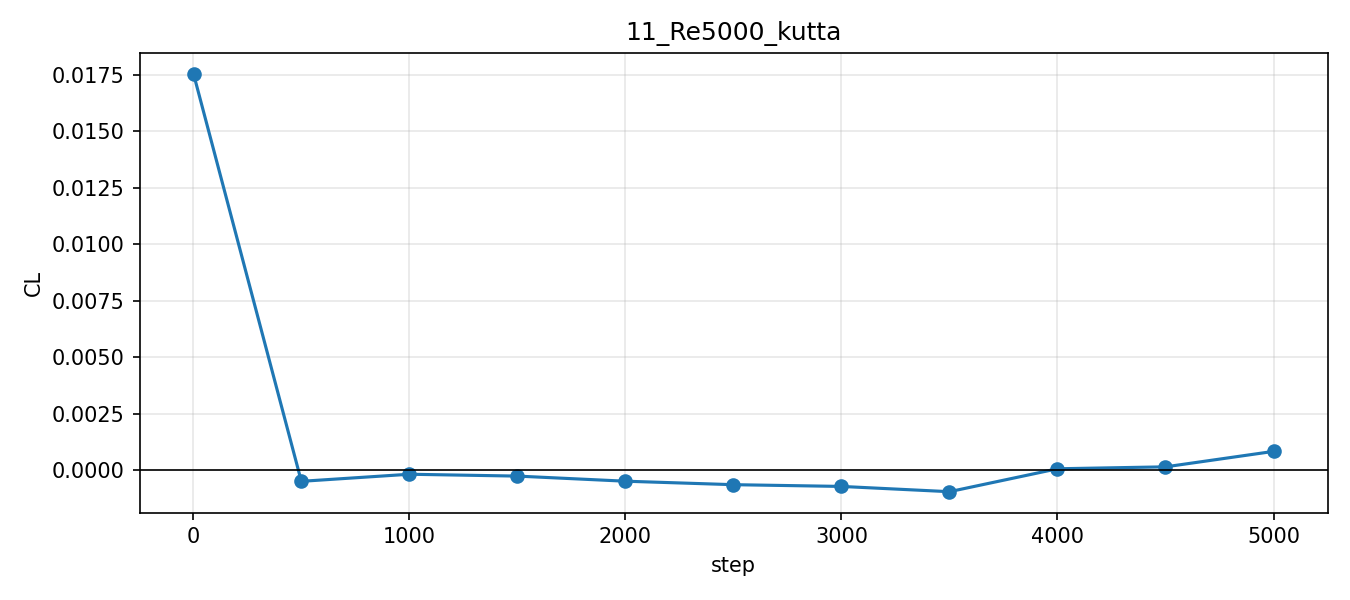

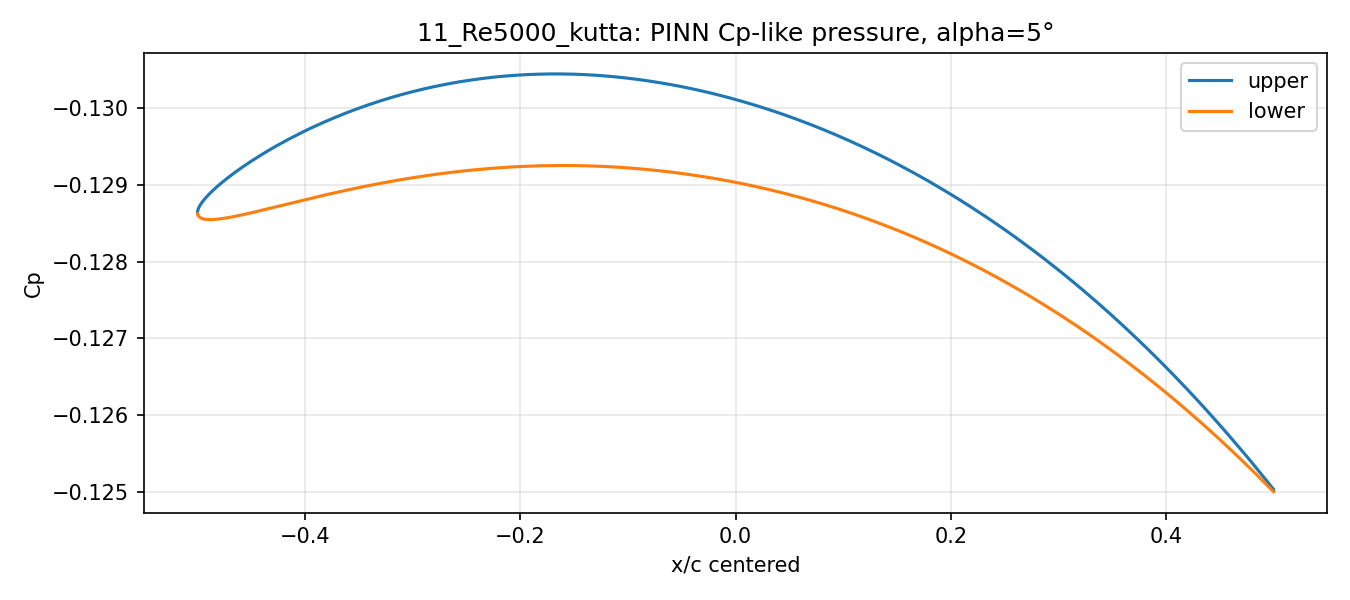


20_xfoil_data_only_surface


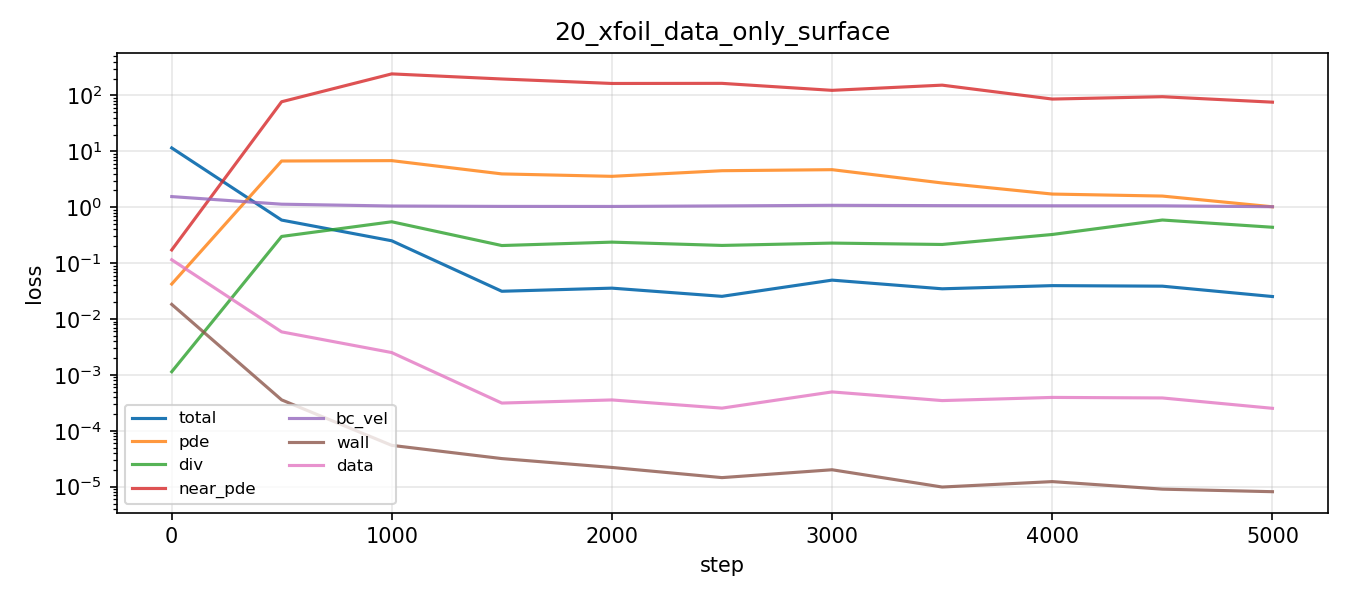

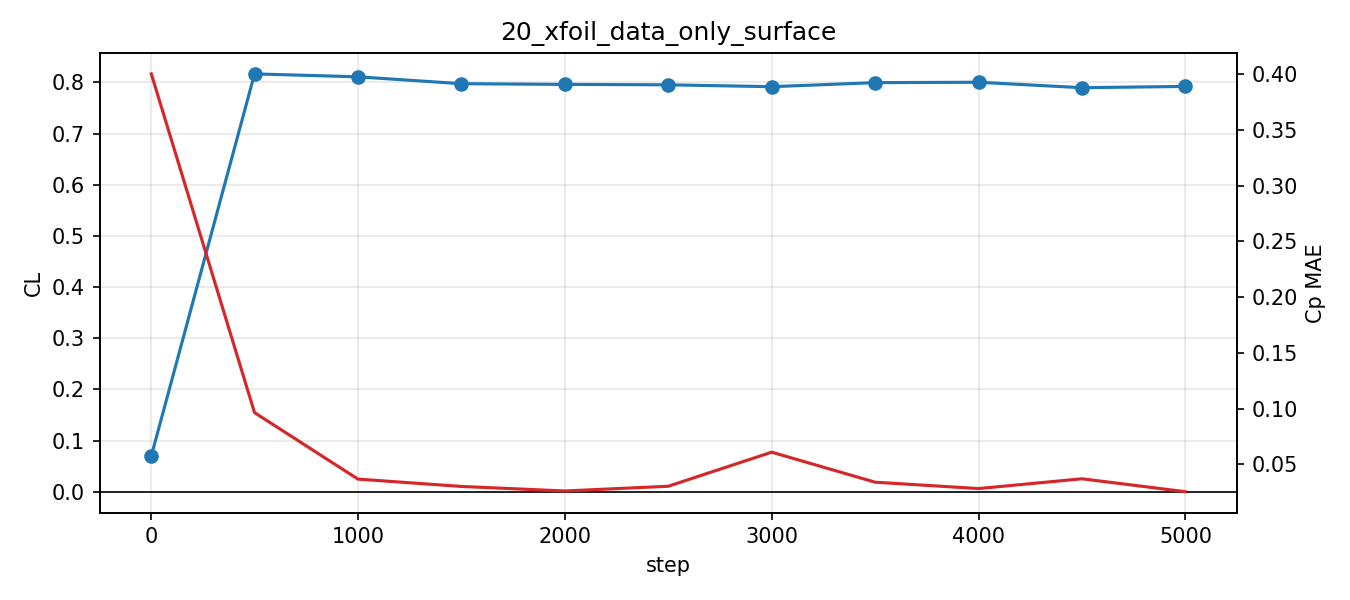

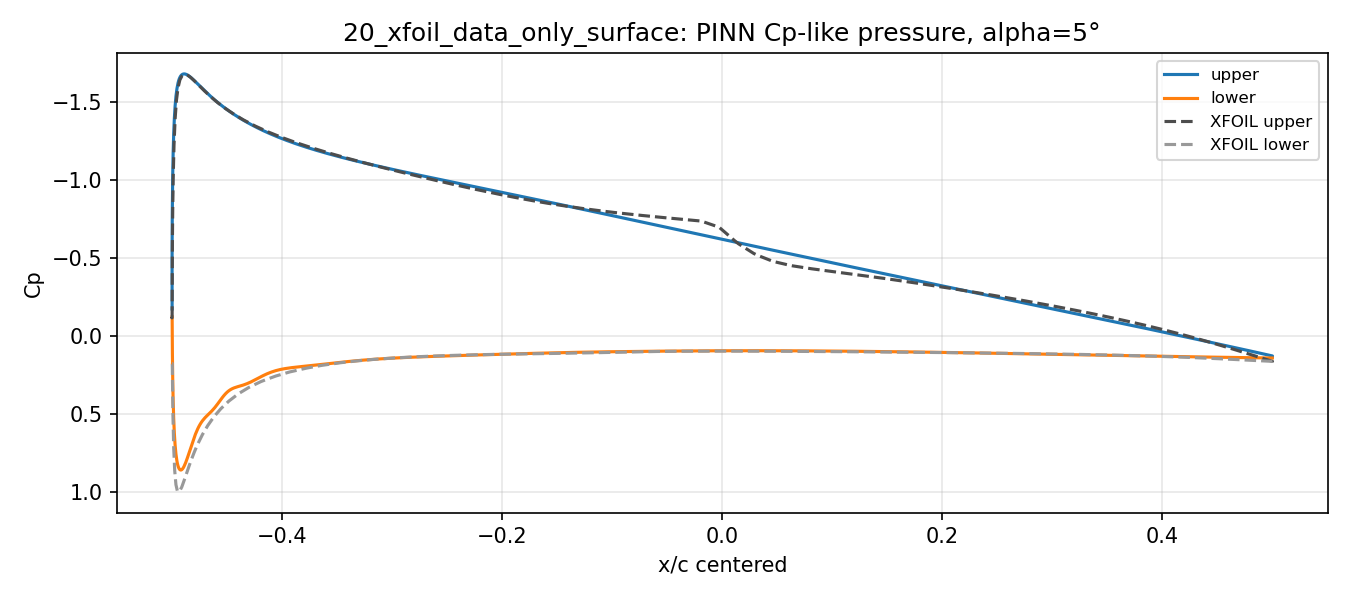


21_xfoil_data_weakPDE


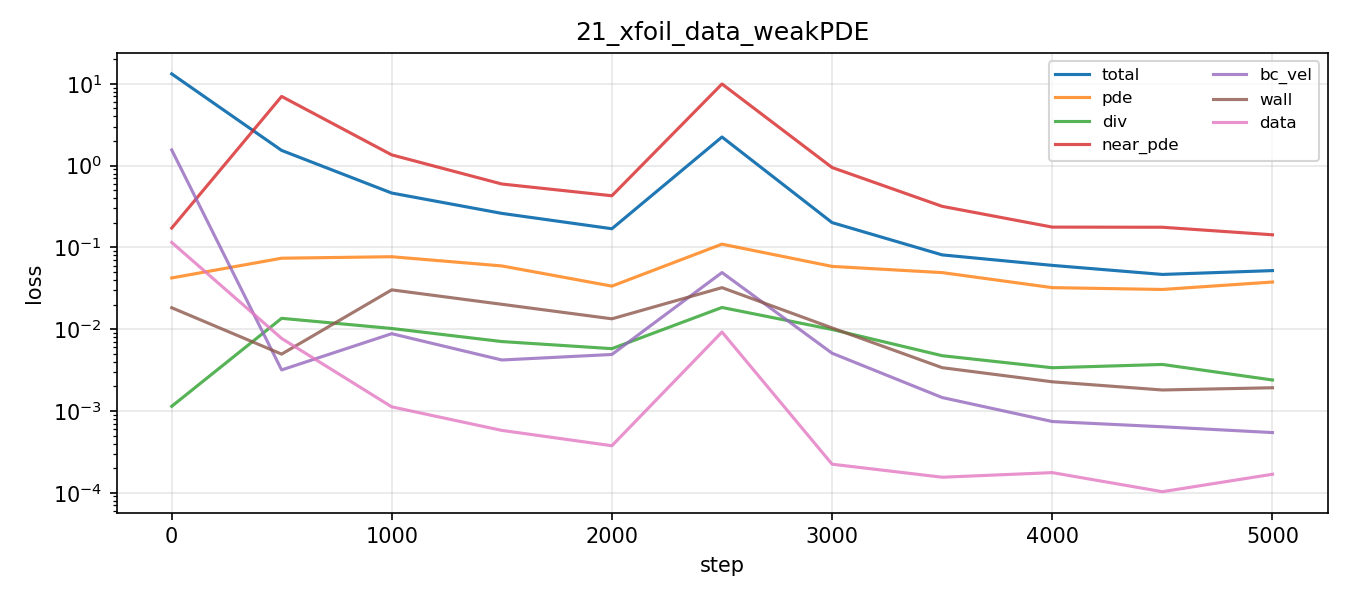

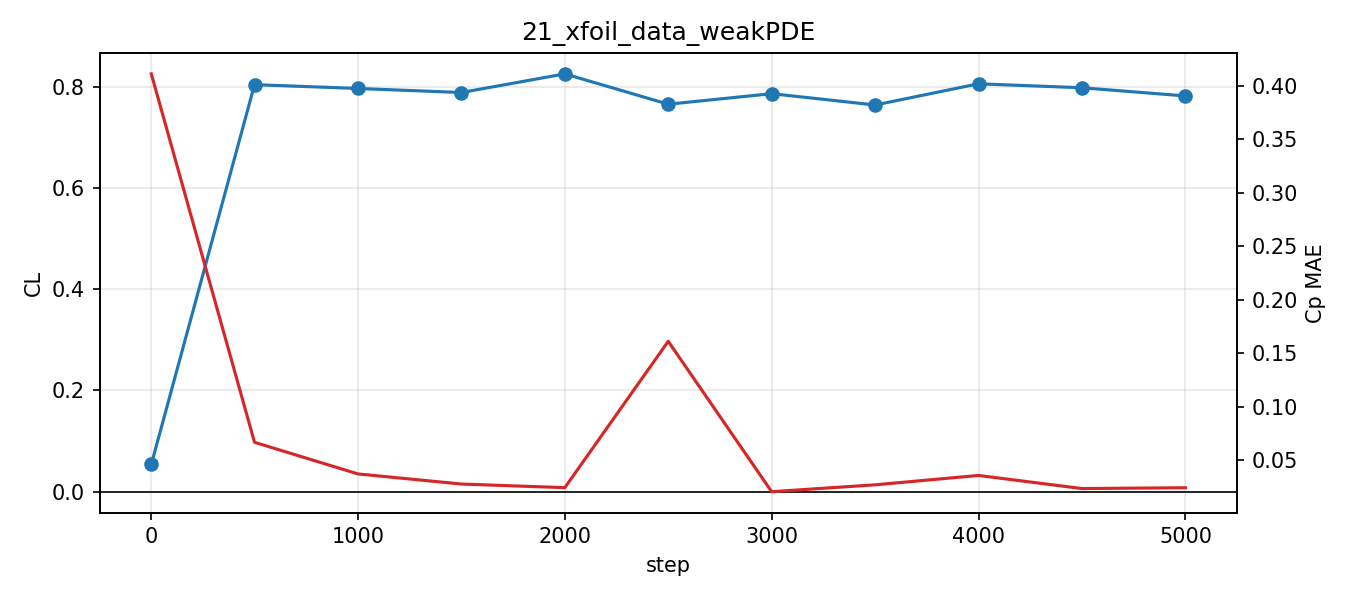

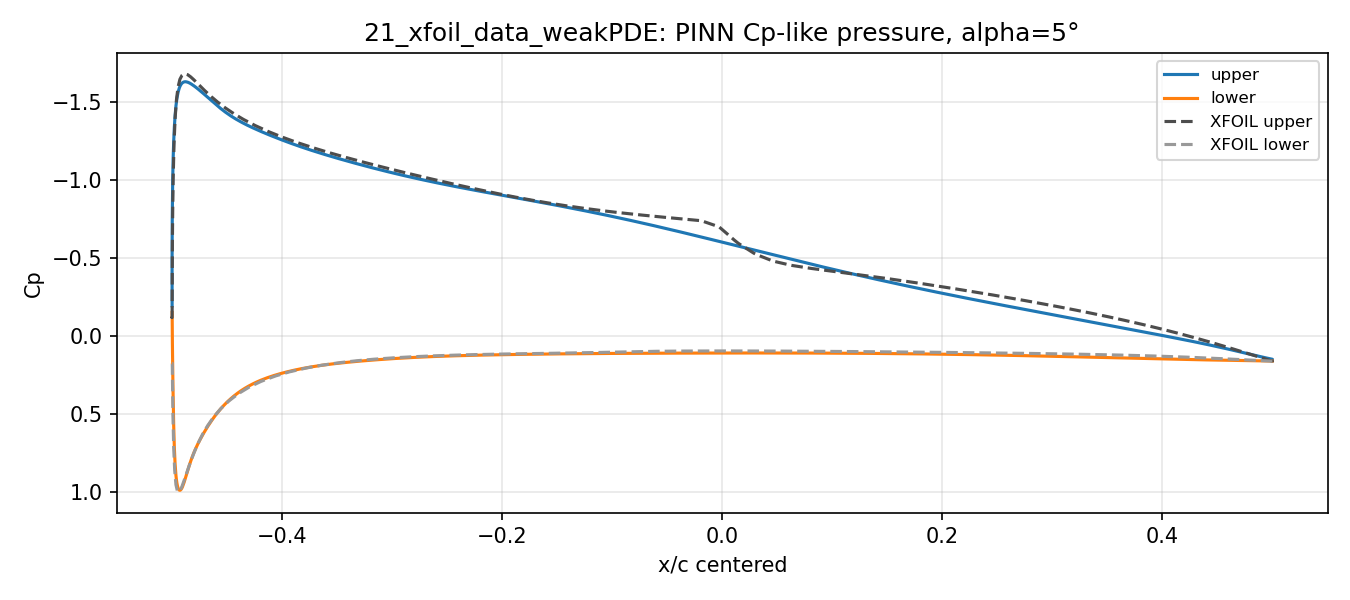

In [7]:

from IPython.display import Image, display

if OUTDIR.exists():
    for case_dir in sorted([p for p in OUTDIR.iterdir() if p.is_dir()]):
        if not (case_dir / "history.csv").exists():
            continue
        print("\n" + "="*90)
        print(case_dir.name)
        print("="*90)
        for fname in ["losses.png", "CL_history.png", "surface_Cp.png"]:
            p = case_dir / fname
            if p.exists():
                display(Image(filename=str(p), width=850))



## 6. Interprétation scientifique des échecs

Les observations attendues sont :

1. **Baseline PINN** : il apprend facilement une vitesse proche du freestream et le no-slip, mais pas la circulation correcte autour du profil.
2. **Pression à zéro sur les frontières** : cela peut contraindre trop fortement le champ de pression et tuer la portance.
3. **Gauge ponctuel** : c'est plus propre, mais ça ne suffit pas à sélectionner la branche portante.
4. **Fourier features** : meilleure capacité de représentation locale, mais pas suffisante pour choisir la bonne solution globale.
5. **Kutta locale** : condition physiquement motivée, mais trop locale pour imposer une circulation globale dans ce paysage d'optimisation.
6. **Reynolds sweep** : augmenter Re ne résout pas le problème dans notre PINN ; la portance reste proche de zéro.



## 7. Contrôle avec données XFOIL

Quand on ajoute une supervision de surface \(C_p\), même faible ou partielle, le problème change complètement : le modèle apprend une distribution de pression non symétrique, donc une vraie portance. C'est exactement ce qui a motivé le passage à la V9 supervisée.


In [8]:

hist_data = lab.historical_data_prior_table()
display(hist_data)

if len(summary) and "w_data" in summary.columns:
    data_cases = summary[pd.to_numeric(summary["w_data"], errors="coerce").fillna(0) > 0]
    if len(data_cases):
        display(data_cases[["case", "CL_pressure", "CL_xfoil", "Cp_MAE_vs_XFOIL", "final_loss", "case_dir"]])


,run,CL_5deg,data_mse,comment
0,V8 XFOIL data 200k + normal PDE,0.447,0.2760,works but PDE conflicts with data
1,"V8 XFOIL data 200k + Kutta, Adam only",0.430,0.2830,"Adam OK, LBFGS became unstable"
2,V8 data-prior 200k + weak PDE,0.758,0.0087,best V8 data-prior fit
3,V8 data-prior 20k + weak PDE,0.249,0.0024,stable but lower lift
4,V9 supervised Cp surrogate,0.805,0.0012,final chosen approach


,case,CL_pressure,CL_xfoil,Cp_MAE_vs_XFOIL,final_loss,case_dir
13,20_xfoil_data_only_surface,0.792201,0.799414,0.025520,0.025266,runs_pinn_failure_v2_full\20_xfoil_data_only_s...
14,21_xfoil_data_weakPDE,0.781657,0.799414,0.024541,0.052015,runs_pinn_failure_v2_full\21_xfoil_data_weakPDE



## 8. Comparaison directe XFOIL si le CSV est disponible

Cette section intègre directement les \(C_p\) XFOIL sur la même quadrature que le PINN. Cela donne une cible physique claire : à \(5^\circ\), on doit obtenir un \(C_L\) d'ordre \(0.5-1\), pas \(10^{-3}\).


In [9]:

if CPDATA.exists():
    xdf = lab.load_xfoil_cp_csv(CPDATA)
    rows = []
    for a in [-20, -15, -10, -5, 0, 5, 10, 15, 20]:
        if np.isclose(xdf["alpha_deg"], a).any():
            cp = lab.cp_from_xfoil_interpolated(xdf, surface, a)
            co = lab.integrate_pressure_coefficients(surface, cp, a)
            rows.append({"alpha_deg": a, **co})
    xfoil_sweep = pd.DataFrame(rows)
    display(xfoil_sweep)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(xfoil_sweep["alpha_deg"], xfoil_sweep["CL_pressure"], marker="o")
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xlabel("alpha [deg]")
    ax.set_ylabel("CL from XFOIL Cp")
    ax.set_title("Portance obtenue par intégration directe des données XFOIL")
    plt.show()

    for a in [5, 20]:
        if np.isclose(xdf["alpha_deg"], a).any():
            cp = lab.cp_from_xfoil_interpolated(xdf, surface, a)
            fig, ax = plt.subplots(figsize=(9, 4))
            lab.plot_surface_cp(surface, cp, ax=ax, title=f"XFOIL Cp intégré, alpha={a}°")
            plt.show()
else:
    print("No XFOIL CSV found. Set CPDATA to your xfoil_cp_dataset.csv path.")


No XFOIL CSV found. Set CPDATA to your xfoil_cp_dataset.csv path.



## 9. Conclusion à montrer au professeur

La conclusion honnête est :

- La formulation PINN pure est mathématiquement séduisante, mais dans notre implémentation elle converge vers une solution quasi non portante.
- Les modifications raisonnables que nous avons testées ne suffisent pas : domaine plus grand, pression gauge ponctuelle, Fourier features, Kutta locale, Reynolds plus élevé.
- Le problème semble être un problème de sélection de branche / paysage d'optimisation : la solution freestream corrigée localement est beaucoup plus accessible que la solution circulante portante.
- Dès qu'on introduit une information globale de surface via XFOIL, la distribution de pression devient correcte.
- La solution finale du projet est donc un surrogate supervisé \((x,y,\mathrm{side},\sin\alpha,\cos\alpha)\mapsto C_p\), intégré dans Unreal par quadrature de pression.
